In [1]:
# ============================================================
#  THESIS: Predicting Train Delays — Deutsche Bahn
#  PHASE 1B · EXPLORATORY DATA ANALYSIS
#  (run AFTER Phase 1 — loads db_train.parquet which contains
#   all engineered features: geo, weather, lag, congestion)
#
#  ANALYSIS ON TRAINING SET ONLY — no test-set peeking.
#  25 visualisations / question blocks:
#   Q1  Target distribution & class balance
#   Q2  Delay by hour of day
#   Q3  Delay by day of week
#   Q4  Delay by month / season
#   Q5  Delay by train type
#   Q6  Stop number vs delay (delay build-up along route)
#   Q7  Lag feature vs actual delay (autocorrelation)
#   Q8  Delay propagation: rolling-3 vs current
#   Q9  Station-level delay heatmap (top-50 worst)
#   Q10 Geographic delay map (lat/lon scatter)
#   Q11 Weather cell delay map
#   Q12 Temperature vs delay
#   Q13 Precipitation vs delay
#   Q14 Wind speed vs delay
#   Q15 Winter severity vs delay
#   Q16 Congestion (trains/hour) vs delay
#   Q17 Planned dwell time vs delay
#   Q18 First-stop vs mid-route vs terminus delay
#   Q19 Correlation heatmap (numeric features vs target)
#   Q20 Delay by time bucket (rush vs off-peak vs night)
#   Q21 Severe delay (>15 min) rate by hour
#   Q22 Delay CDF — how often are trains within 5 / 10 min?
#   Q23 Train name (line) top-20 worst performers
#   Q24 Weather disruption index vs delay class
#   Q25 Combined: weather × rush hour interaction
# ============================================================

# ════════════════════════════════════════════════════════════
# CELL EDA-1 · IMPORTS & LOAD
# ════════════════════════════════════════════════════════════

import warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import pearsonr, spearmanr

warnings.filterwarnings("ignore")
np.random.seed(42)

OUTPUT_DIR = Path("outputs")
FIG_DIR    = OUTPUT_DIR / "figures" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
PAL     = sns.color_palette("muted",    12)
PAL_DIV = sns.color_palette("RdYlGn_r", 10)
FIG_DPI = 150

# ── Load train split (all features present) ──────────────────
df = pd.read_parquet(OUTPUT_DIR / "db_train.parquet")

with open(OUTPUT_DIR / "config.json") as f:
    cfg = json.load(f)

WEATHER_FEATURES    = cfg["WEATHER_FEATURES"]
LAG_FEATURES        = cfg["LAG_FEATURES"]
CONGESTION_FEATURES = cfg["CONGESTION_FEATURES"]

CLASS_LABELS = {
    0: "On time/early (≤0 min)",
    1: "Slight delay  (1–5 min)",
    2: "Moderate      (6–15 min)",
    3: "Severe        (>15 min)",
}
CLASS_COLORS = [PAL[2], PAL[0], PAL[1], PAL[3]]

print(f"Training rows loaded : {len(df):,}")
print(f"Columns              : {df.shape[1]}")
print(f"Date range           : {df['departure_planned_time'].min().date()} "
      f"→ {df['departure_planned_time'].max().date()}")
print(f"Unique rides         : {df['train_line_ride_id'].nunique():,}")
print(f"Unique stations      : {df['station_name'].nunique():,}")
print(f"Unique train types   : {df['train_type'].nunique()}")
print(f"\nTarget (delay_in_min):")
print(df["delay_in_min"].describe(
    percentiles=[.01,.05,.25,.5,.75,.90,.95,.99]
).round(3).to_string())


Training rows loaded : 715,232
Columns              : 81
Date range           : 2024-07-01 → 2026-03-31
Unique rides         : 114,497
Unique stations      : 5,338
Unique train types   : 107

Target (delay_in_min):
count    715232.000
mean          2.607
std           5.617
min          -2.000
1%            0.000
5%            0.000
25%           0.000
50%           1.000
75%           2.000
90%           7.000
95%          12.000
99%          31.000
max          44.000


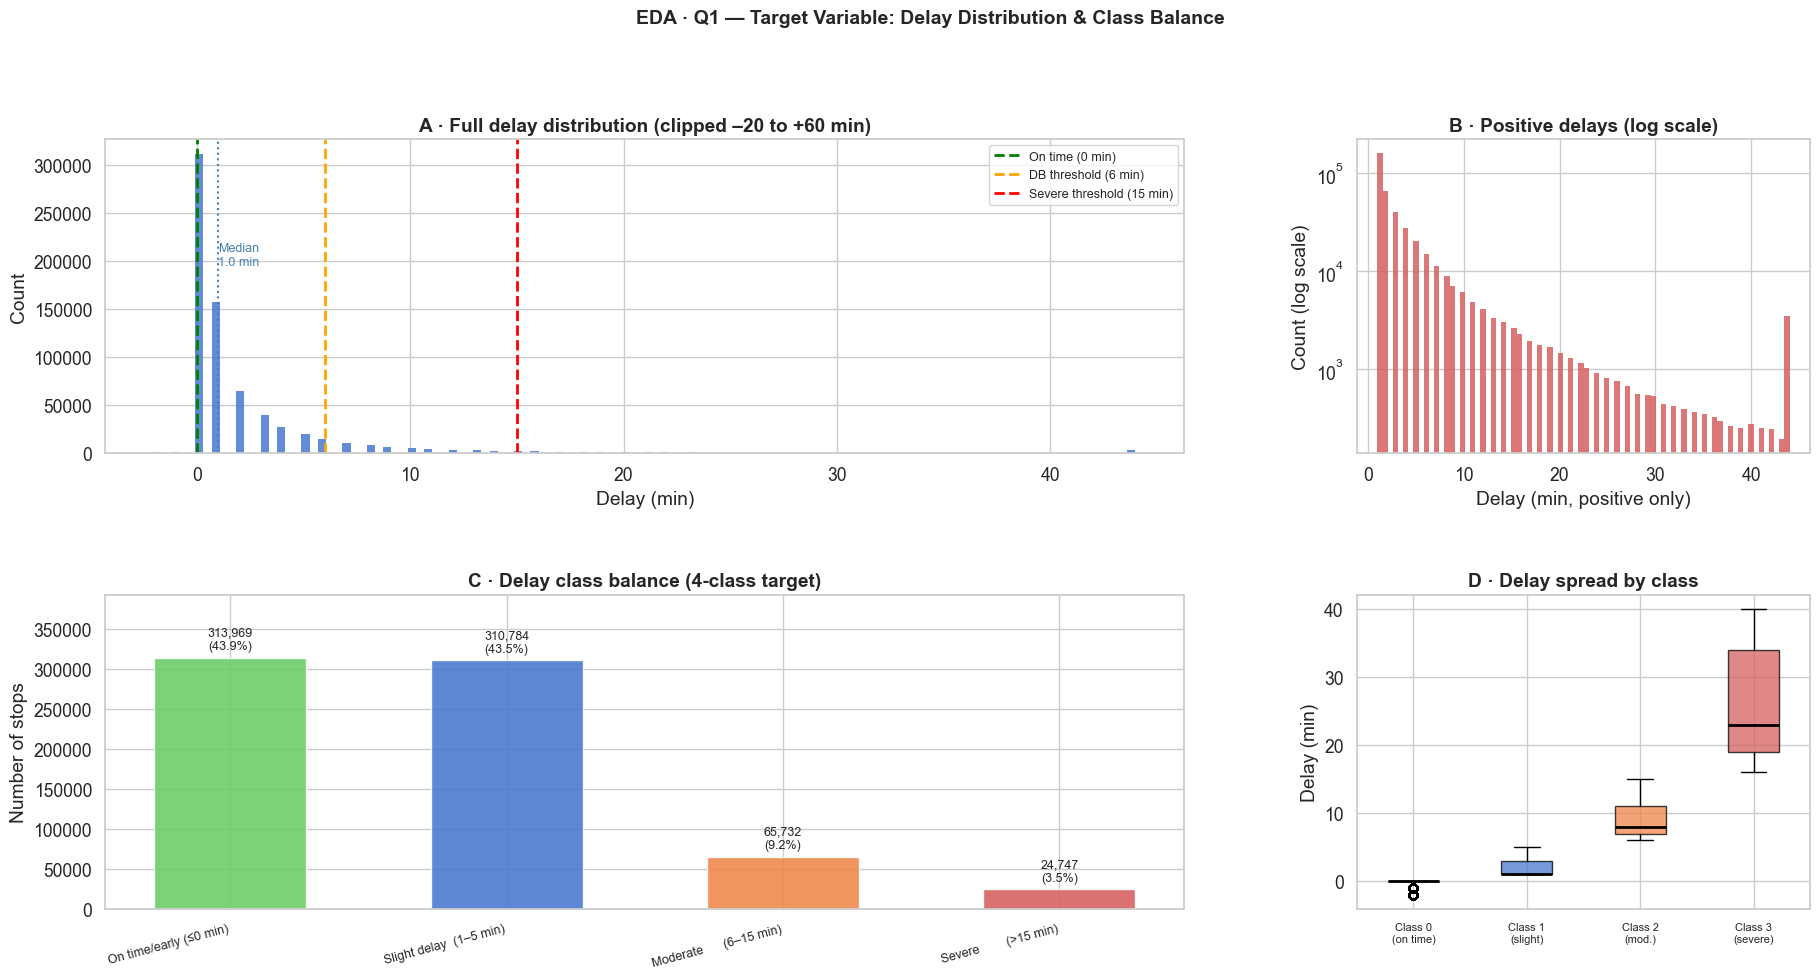

── Q1 Key findings ────────────────────────────────────────
  Early trains    : 0.4%
  On time exactly : 43.5%
  Delayed >6 min  : 10.6%  (DB official definition)
  Delayed >15 min : 3.5%  (severe)
  Delayed >30 min : 1.0%
  Skewness        : 4.331  (right-skewed → rare extreme delays)
  Kurtosis        : 23.094  (heavy tails)


In [3]:
# ════════════════════════════════════════════════════════════
# CELL EDA-2 · Q1 — TARGET DISTRIBUTION & CLASS BALANCE
# ════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(22, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.38)

# Panel A: full histogram
ax1 = fig.add_subplot(gs[0, :2])
ax1.hist(df["delay_in_min"].clip(-20, 60), bins=120,
         color=PAL[0], edgecolor="none", alpha=0.85)
ax1.axvline(0,  color="green",  lw=2, ls="--", label="On time (0 min)")
ax1.axvline(6,  color="orange", lw=2, ls="--", label="DB threshold (6 min)")
ax1.axvline(15, color="red",    lw=2, ls="--", label="Severe threshold (15 min)")
ax1.set_xlabel("Delay (min)"); ax1.set_ylabel("Count")
ax1.set_title("A · Full delay distribution (clipped –20 to +60 min)", fontweight="bold")
ax1.legend(fontsize=9)
# annotate median
med = df["delay_in_min"].median()
ax1.axvline(med, color="steelblue", lw=1.5, ls=":", label=f"Median ({med:.1f} min)")
ax1.annotate(f"Median\n{med:.1f} min", xy=(med, ax1.get_ylim()[1]*0.6),
             fontsize=9, color="steelblue", ha="left")

# Panel B: log-scale for positive tail
ax2 = fig.add_subplot(gs[0, 2])
pos = df.loc[df["delay_in_min"] > 0, "delay_in_min"]
ax2.hist(pos.clip(0, 120), bins=80, color=PAL[3],
         edgecolor="none", alpha=0.85, log=True)
ax2.set_xlabel("Delay (min, positive only)")
ax2.set_ylabel("Count (log scale)")
ax2.set_title("B · Positive delays (log scale)", fontweight="bold")

# Panel C: delay class bar chart
ax3 = fig.add_subplot(gs[1, :2])
cls_counts = df["delay_class"].value_counts().sort_index()
bars = ax3.bar(
    [CLASS_LABELS[k] for k in cls_counts.index],
    cls_counts.values,
    color=CLASS_COLORS, alpha=0.88, width=0.55
)
ax3.bar_label(bars,
              labels=[f"{v:,}\n({v/len(df)*100:.1f}%)" for v in cls_counts.values],
              padding=4, fontsize=9)
ax3.set_ylabel("Number of stops"); ax3.set_ylim(0, cls_counts.max() * 1.25)
ax3.set_title("C · Delay class balance (4-class target)", fontweight="bold")
plt.setp(ax3.get_xticklabels(), rotation=15, ha="right", fontsize=9)

# Panel D: boxplot per class
ax4 = fig.add_subplot(gs[1, 2])
data_by_cls = [df.loc[df["delay_class"] == k, "delay_in_min"].clip(-10, 40).values
               for k in [0, 1, 2, 3]]
bp = ax4.boxplot(data_by_cls, patch_artist=True,
                 medianprops=dict(color="black", lw=2))
for patch, color in zip(bp["boxes"], CLASS_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax4.set_xticklabels(["Class 0\n(on time)", "Class 1\n(slight)",
                     "Class 2\n(mod.)", "Class 3\n(severe)"], fontsize=8)
ax4.set_ylabel("Delay (min)"); ax4.set_title("D · Delay spread by class", fontweight="bold")

fig.suptitle("EDA · Q1 — Target Variable: Delay Distribution & Class Balance",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig(FIG_DIR / "eda_01_target_distribution.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

# Key stats print
print("── Q1 Key findings ────────────────────────────────────────")
print(f"  Early trains    : {(df['delay_in_min']<0).mean()*100:.1f}%")
print(f"  On time exactly : {(df['delay_in_min']==0).mean()*100:.1f}%")
print(f"  Delayed >6 min  : {(df['delay_in_min']>6).mean()*100:.1f}%  (DB official definition)")
print(f"  Delayed >15 min : {(df['delay_in_min']>15).mean()*100:.1f}%  (severe)")
print(f"  Delayed >30 min : {(df['delay_in_min']>30).mean()*100:.1f}%")
print(f"  Skewness        : {df['delay_in_min'].skew():.3f}  (right-skewed → rare extreme delays)")
print(f"  Kurtosis        : {df['delay_in_min'].kurtosis():.3f}  (heavy tails)")


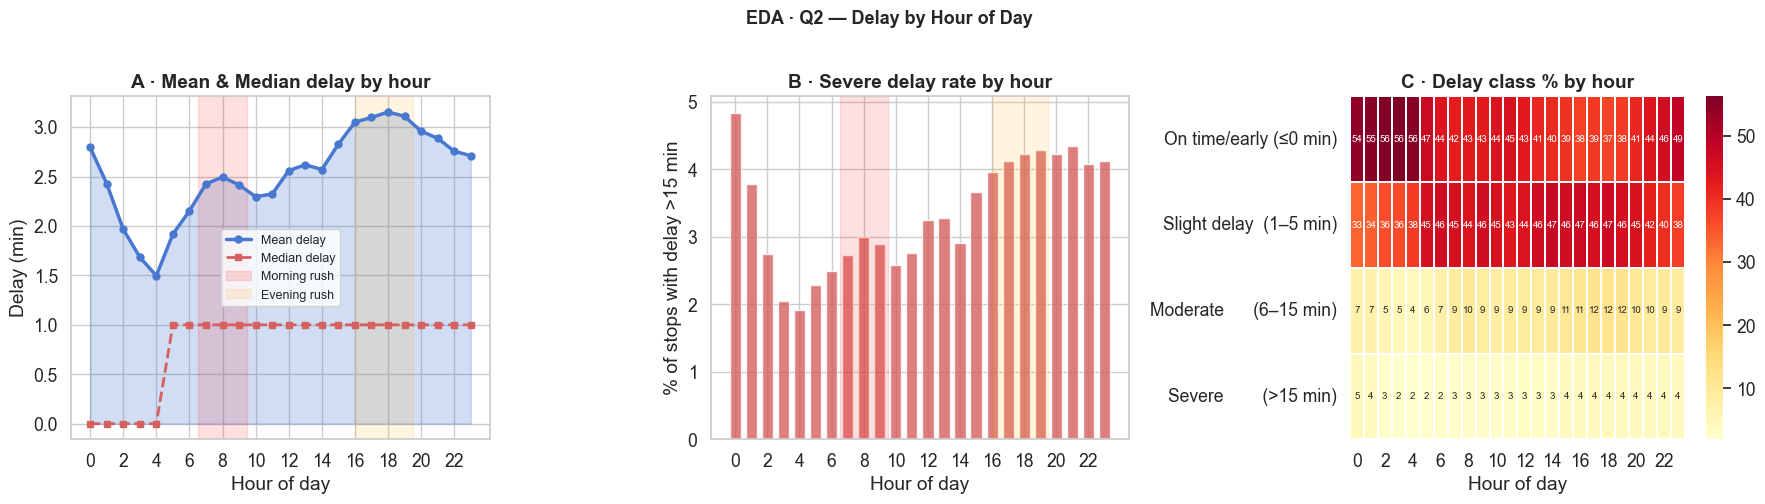

  Worst hour: 18:00  mean=3.15 min  severe_rate=4.2%


In [4]:
# ════════════════════════════════════════════════════════════
# CELL EDA-3 · Q2 — DELAY BY HOUR OF DAY
# ════════════════════════════════════════════════════════════

hourly = (df.groupby("hour")["delay_in_min"]
          .agg(mean="mean", median="median",
               severe_rate=lambda x: (x > 15).mean() * 100,
               n="count")
          .reset_index())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Mean and median
ax = axes[0]
ax.fill_between(hourly["hour"], hourly["mean"], alpha=0.25, color=PAL[0])
ax.plot(hourly["hour"], hourly["mean"],   color=PAL[0], lw=2.5,
        marker="o", ms=5, label="Mean delay")
ax.plot(hourly["hour"], hourly["median"], color=PAL[3], lw=2,
        ls="--", marker="s", ms=4, label="Median delay")
ax.axvspan(6.5, 9.5,  alpha=0.12, color="red",    label="Morning rush")
ax.axvspan(16,  19.5, alpha=0.12, color="orange",  label="Evening rush")
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel("Hour of day")
ax.set_ylabel("Delay (min)"); ax.set_title("A · Mean & Median delay by hour", fontweight="bold")
ax.legend(fontsize=9)

# Severe delay rate
ax = axes[1]
ax.bar(hourly["hour"], hourly["severe_rate"], color=PAL[3], alpha=0.8, width=0.7)
ax.axvspan(6.5, 9.5,  alpha=0.12, color="red")
ax.axvspan(16,  19.5, alpha=0.12, color="orange")
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel("Hour of day")
ax.set_ylabel("% of stops with delay >15 min")
ax.set_title("B · Severe delay rate by hour", fontweight="bold")

# Heatmap: hour × delay_class proportion
pivot_h = (df.groupby(["hour", "delay_class"])
             .size()
             .unstack(fill_value=0))
pivot_h = pivot_h.div(pivot_h.sum(axis=1), axis=0) * 100
ax = axes[2]
sns.heatmap(pivot_h.T, ax=ax, cmap="YlOrRd", fmt=".0f", annot=True,
            annot_kws={"size": 7}, linewidths=0.3,
            yticklabels=[CLASS_LABELS[k] for k in [0,1,2,3]])
ax.set_xlabel("Hour of day"); ax.set_ylabel("")
ax.set_title("C · Delay class % by hour", fontweight="bold")

fig.suptitle("EDA · Q2 — Delay by Hour of Day",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_02_delay_by_hour.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

peak_hour = hourly.loc[hourly["mean"].idxmax()]
print(f"  Worst hour: {int(peak_hour['hour']):02d}:00  "
      f"mean={peak_hour['mean']:.2f} min  "
      f"severe_rate={peak_hour['severe_rate']:.1f}%")


  Friday mean: 3.42 min  |  Monday mean: 3.04 min
  Weekend avg: 2.21 min  vs Weekday avg: 3.00 min


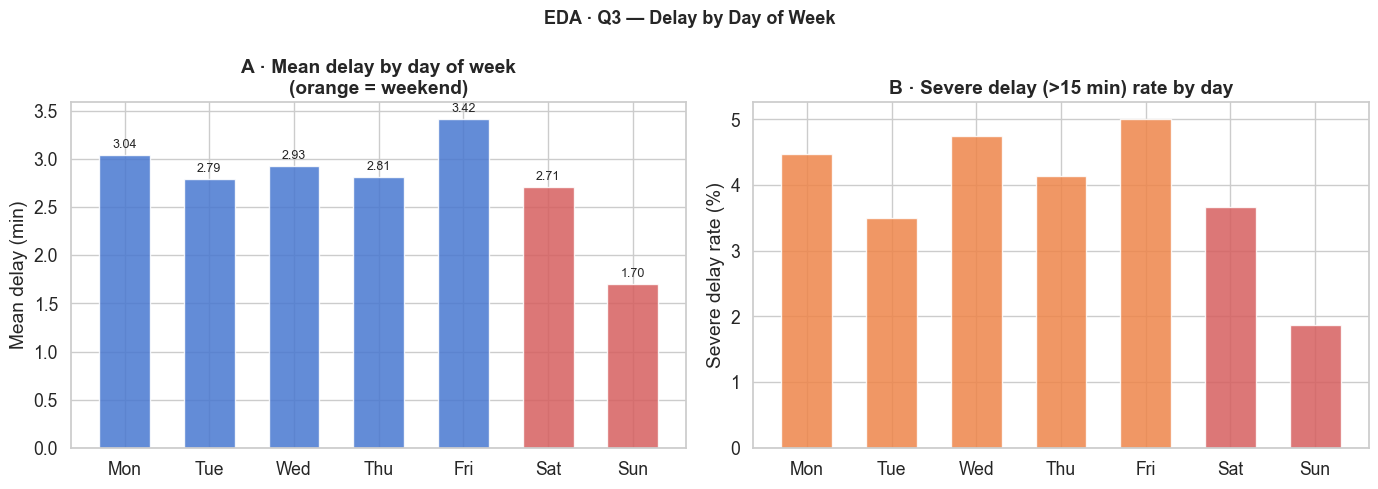

In [5]:
# ════════════════════════════════════════════════════════════
# CELL EDA-4 · Q3 — DELAY BY DAY OF WEEK
# ════════════════════════════════════════════════════════════

DAY_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

daily = (df.groupby("day_of_week")["delay_in_min"]
         .agg(mean="mean", median="median",
              severe=lambda x: (x>15).mean()*100,
              n="count")
         .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bars = ax.bar(DAY_NAMES, daily["mean"],
              color=[PAL[3] if i >= 5 else PAL[0] for i in range(7)],
              alpha=0.85, width=0.6)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
ax.set_ylabel("Mean delay (min)")
ax.set_title("A · Mean delay by day of week\n(orange = weekend)", fontweight="bold")

ax = axes[1]
ax.bar(DAY_NAMES, daily["severe"],
       color=[PAL[3] if i >= 5 else PAL[1] for i in range(7)],
       alpha=0.85, width=0.6)
ax.set_ylabel("Severe delay rate (%)")
ax.set_title("B · Severe delay (>15 min) rate by day", fontweight="bold")

# Annotation: Friday effect
fri_mean = daily.loc[daily["day_of_week"]==4, "mean"].values[0]
mon_mean = daily.loc[daily["day_of_week"]==0, "mean"].values[0]
print(f"  Friday mean: {fri_mean:.2f} min  |  Monday mean: {mon_mean:.2f} min")
print(f"  Weekend avg: {daily.loc[daily['day_of_week']>=5,'mean'].mean():.2f} min  "
      f"vs Weekday avg: {daily.loc[daily['day_of_week']<5,'mean'].mean():.2f} min")

fig.suptitle("EDA · Q3 — Delay by Day of Week",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_03_delay_by_dow.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


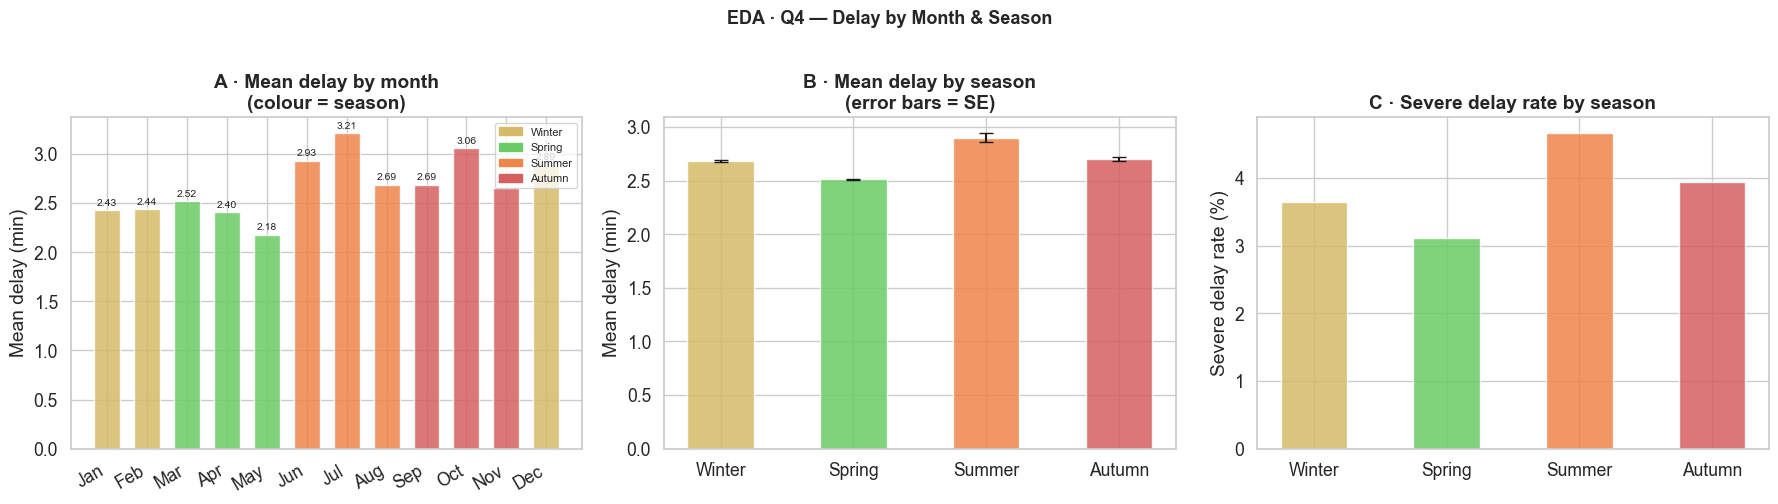

  Seasonal mean delays:
    Winter  : 2.68 min  severe=3.6%  n=226,950
    Spring  : 2.51 min  severe=3.1%  n=357,163
    Summer  : 2.90 min  severe=4.7%  n=24,620
    Autumn  : 2.70 min  severe=3.9%  n=106,499


In [6]:
# ════════════════════════════════════════════════════════════
# CELL EDA-5 · Q4 — DELAY BY MONTH & SEASON
# ════════════════════════════════════════════════════════════

MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
SEASON_NAMES = {0:"Winter", 1:"Spring", 2:"Summer", 3:"Autumn"}
SEASON_COLORS = {0:PAL[8], 1:PAL[2], 2:PAL[1], 3:PAL[3]}

monthly = (df.groupby("month")["delay_in_min"]
           .agg(mean="mean", median="median",
                severe=lambda x: (x>15).mean()*100,
                n="count")
           .reset_index())

seasonal = (df.groupby("season")["delay_in_min"]
            .agg(mean="mean", std="std", n="count",
                 severe=lambda x: (x>15).mean()*100)
            .reset_index())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
m_idx = monthly["month"].values - 1
bar_colors = [SEASON_COLORS[0] if m in [0,1,11] else
              SEASON_COLORS[1] if m in [2,3,4]  else
              SEASON_COLORS[2] if m in [5,6,7]  else
              SEASON_COLORS[3] for m in m_idx]
bars = ax.bar([MONTH_NAMES[i] for i in m_idx],
              monthly["mean"], color=bar_colors, alpha=0.85, width=0.65)
ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=7.5)
ax.set_ylabel("Mean delay (min)")
ax.set_title("A · Mean delay by month\n(colour = season)", fontweight="bold")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

from matplotlib.patches import Patch
season_legend = [Patch(color=SEASON_COLORS[k], label=SEASON_NAMES[k])
                 for k in range(4)]
ax.legend(handles=season_legend, fontsize=8, loc="upper right")

ax = axes[1]
ax.bar([SEASON_NAMES[s] for s in seasonal["season"]],
       seasonal["mean"],
       color=[SEASON_COLORS[s] for s in seasonal["season"]],
       alpha=0.85, width=0.5,
       yerr=seasonal["std"]/np.sqrt(seasonal["n"]),
       capsize=5)
ax.set_ylabel("Mean delay (min)")
ax.set_title("B · Mean delay by season\n(error bars = SE)", fontweight="bold")

ax = axes[2]
ax.bar([SEASON_NAMES[s] for s in seasonal["season"]],
       seasonal["severe"],
       color=[SEASON_COLORS[s] for s in seasonal["season"]],
       alpha=0.85, width=0.5)
ax.set_ylabel("Severe delay rate (%)")
ax.set_title("C · Severe delay rate by season", fontweight="bold")

fig.suptitle("EDA · Q4 — Delay by Month & Season",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_04_delay_by_month.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

print("  Seasonal mean delays:")
for _, row in seasonal.iterrows():
    print(f"    {SEASON_NAMES[int(row['season'])]:8s}: "
          f"{row['mean']:.2f} min  severe={row['severe']:.1f}%  n={int(row['n']):,}")


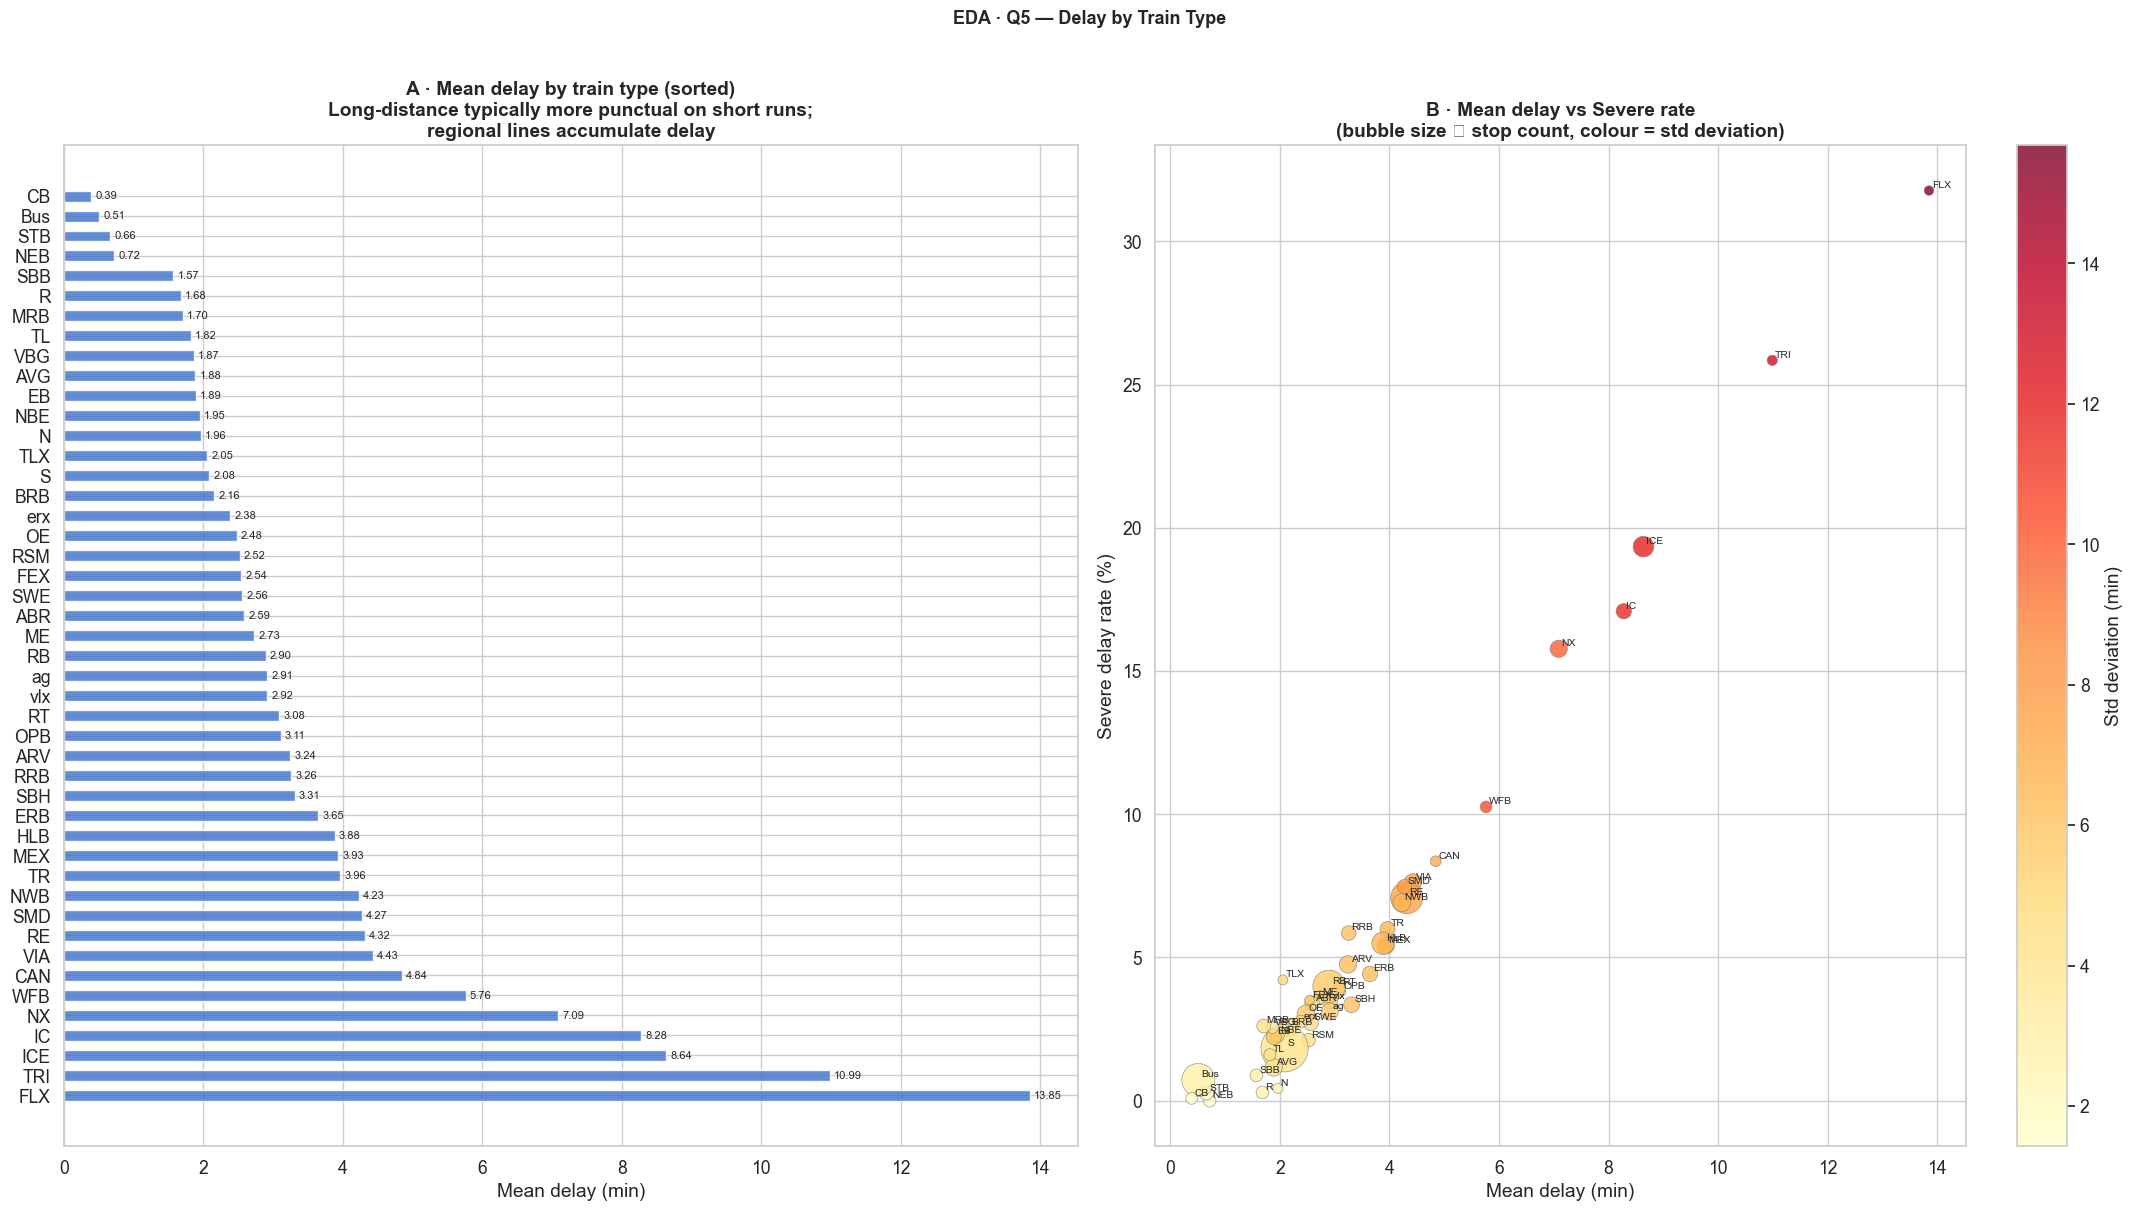

In [8]:
# ════════════════════════════════════════════════════════════
# CELL EDA-6 · Q5 — DELAY BY TRAIN TYPE
# ════════════════════════════════════════════════════════════

type_stats = (df.groupby("train_type")["delay_in_min"]
              .agg(mean="mean", median="median", std="std",
                   severe=lambda x: (x>15).mean()*100,
                   n="count")
              .reset_index()
              .sort_values("mean", ascending=False))

# Only show types with at least 500 stops
type_stats = type_stats[type_stats["n"] >= 500].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(22, 12))

ax = axes[0]
bars = ax.barh(type_stats["train_type"], type_stats["mean"],
               color=PAL[0], alpha=0.85, height=0.55)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
ax.set_xlabel("Mean delay (min)")
ax.set_title("A · Mean delay by train type (sorted)\n"
             "Long-distance typically more punctual on short runs;\n"
             "regional lines accumulate delay", fontweight="bold")

ax = axes[1]
# Scatter: mean delay vs severe rate, bubble = n
sc = ax.scatter(type_stats["mean"], type_stats["severe"],
                s=np.sqrt(type_stats["n"]) * 2,
                c=type_stats["std"], cmap="YlOrRd", alpha=0.8,
                edgecolors="grey", lw=0.5)
for _, row in type_stats.iterrows():
    ax.annotate(row["train_type"],
                (row["mean"] + 0.05, row["severe"] + 0.1),
                fontsize=7.5)
plt.colorbar(sc, ax=ax, label="Std deviation (min)")
ax.set_xlabel("Mean delay (min)")
ax.set_ylabel("Severe delay rate (%)")
ax.set_title("B · Mean delay vs Severe rate\n(bubble size ∝ stop count, "
             "colour = std deviation)", fontweight="bold")

fig.suptitle("EDA · Q5 — Delay by Train Type",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_05_delay_by_train_type.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


  Pearson r (stop_number vs mean_delay) = 0.896  p=9.694e-12


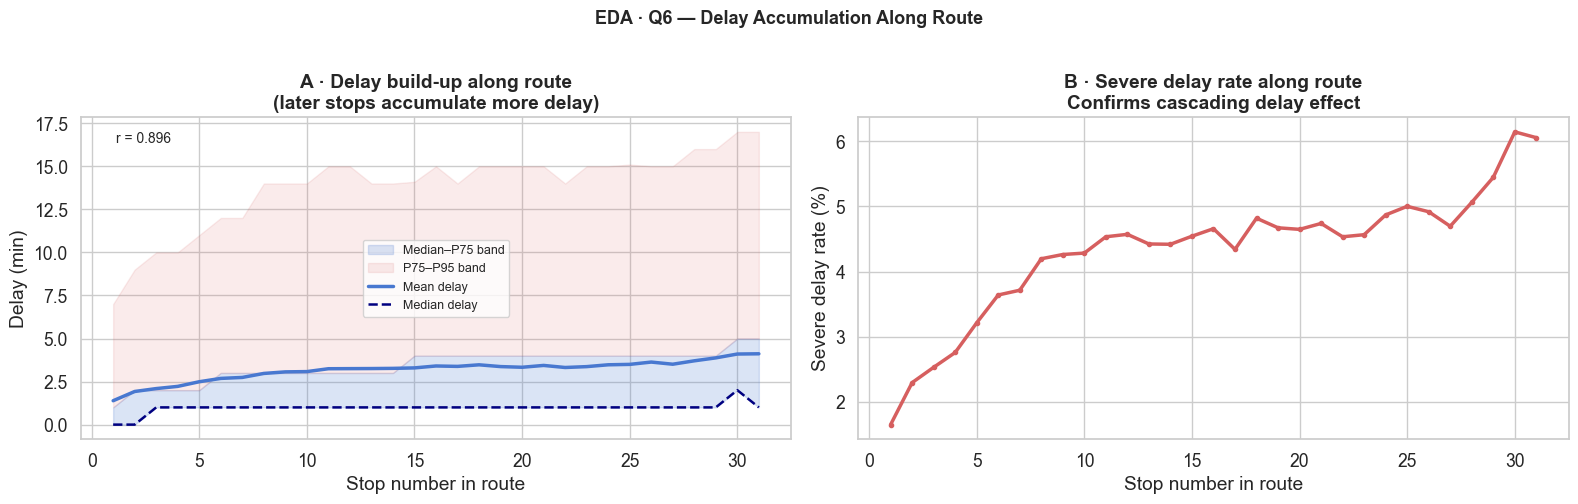

In [9]:
# ════════════════════════════════════════════════════════════
# CELL EDA-7 · Q6 — STOP NUMBER: DELAY BUILD-UP ALONG ROUTE
# ════════════════════════════════════════════════════════════

# Sample rides to keep runtime manageable
max_stop = int(df["stop_number"].quantile(0.99))
stop_stats = (df[df["stop_number"] <= max_stop]
              .groupby("stop_number")["delay_in_min"]
              .agg(mean="mean", median="median",
                   p75=lambda x: x.quantile(0.75),
                   p95=lambda x: x.quantile(0.95),
                   severe=lambda x: (x>15).mean()*100,
                   n="count")
              .reset_index())

# Keep only stop numbers with >= 100 observations
stop_stats = stop_stats[stop_stats["n"] >= 100]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.fill_between(stop_stats["stop_number"], stop_stats["median"],
                stop_stats["p75"], alpha=0.2, color=PAL[0], label="Median–P75 band")
ax.fill_between(stop_stats["stop_number"], stop_stats["p75"],
                stop_stats["p95"], alpha=0.12, color=PAL[3], label="P75–P95 band")
ax.plot(stop_stats["stop_number"], stop_stats["mean"],
        color=PAL[0], lw=2.5, label="Mean delay")
ax.plot(stop_stats["stop_number"], stop_stats["median"],
        color="navy", lw=1.8, ls="--", label="Median delay")
ax.set_xlabel("Stop number in route"); ax.set_ylabel("Delay (min)")
ax.set_title("A · Delay build-up along route\n"
             "(later stops accumulate more delay)", fontweight="bold")
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(stop_stats["stop_number"], stop_stats["severe"],
        color=PAL[3], lw=2.5, marker="o", ms=3)
ax.set_xlabel("Stop number in route")
ax.set_ylabel("Severe delay rate (%)")
ax.set_title("B · Severe delay rate along route\n"
             "Confirms cascading delay effect", fontweight="bold")

# Pearson correlation
r, p = pearsonr(stop_stats["stop_number"], stop_stats["mean"])
print(f"  Pearson r (stop_number vs mean_delay) = {r:.3f}  p={p:.3e}")
axes[0].text(0.05, 0.92, f"r = {r:.3f}", transform=axes[0].transAxes,
             fontsize=10, bbox=dict(boxstyle="round", fc="white", alpha=0.8))

fig.suptitle("EDA · Q6 — Delay Accumulation Along Route",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_06_delay_by_stop_number.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


  When prev stop delayed >6 min → current mean: 14.90 min
  When prev stop NOT delayed    → current mean: 1.38 min


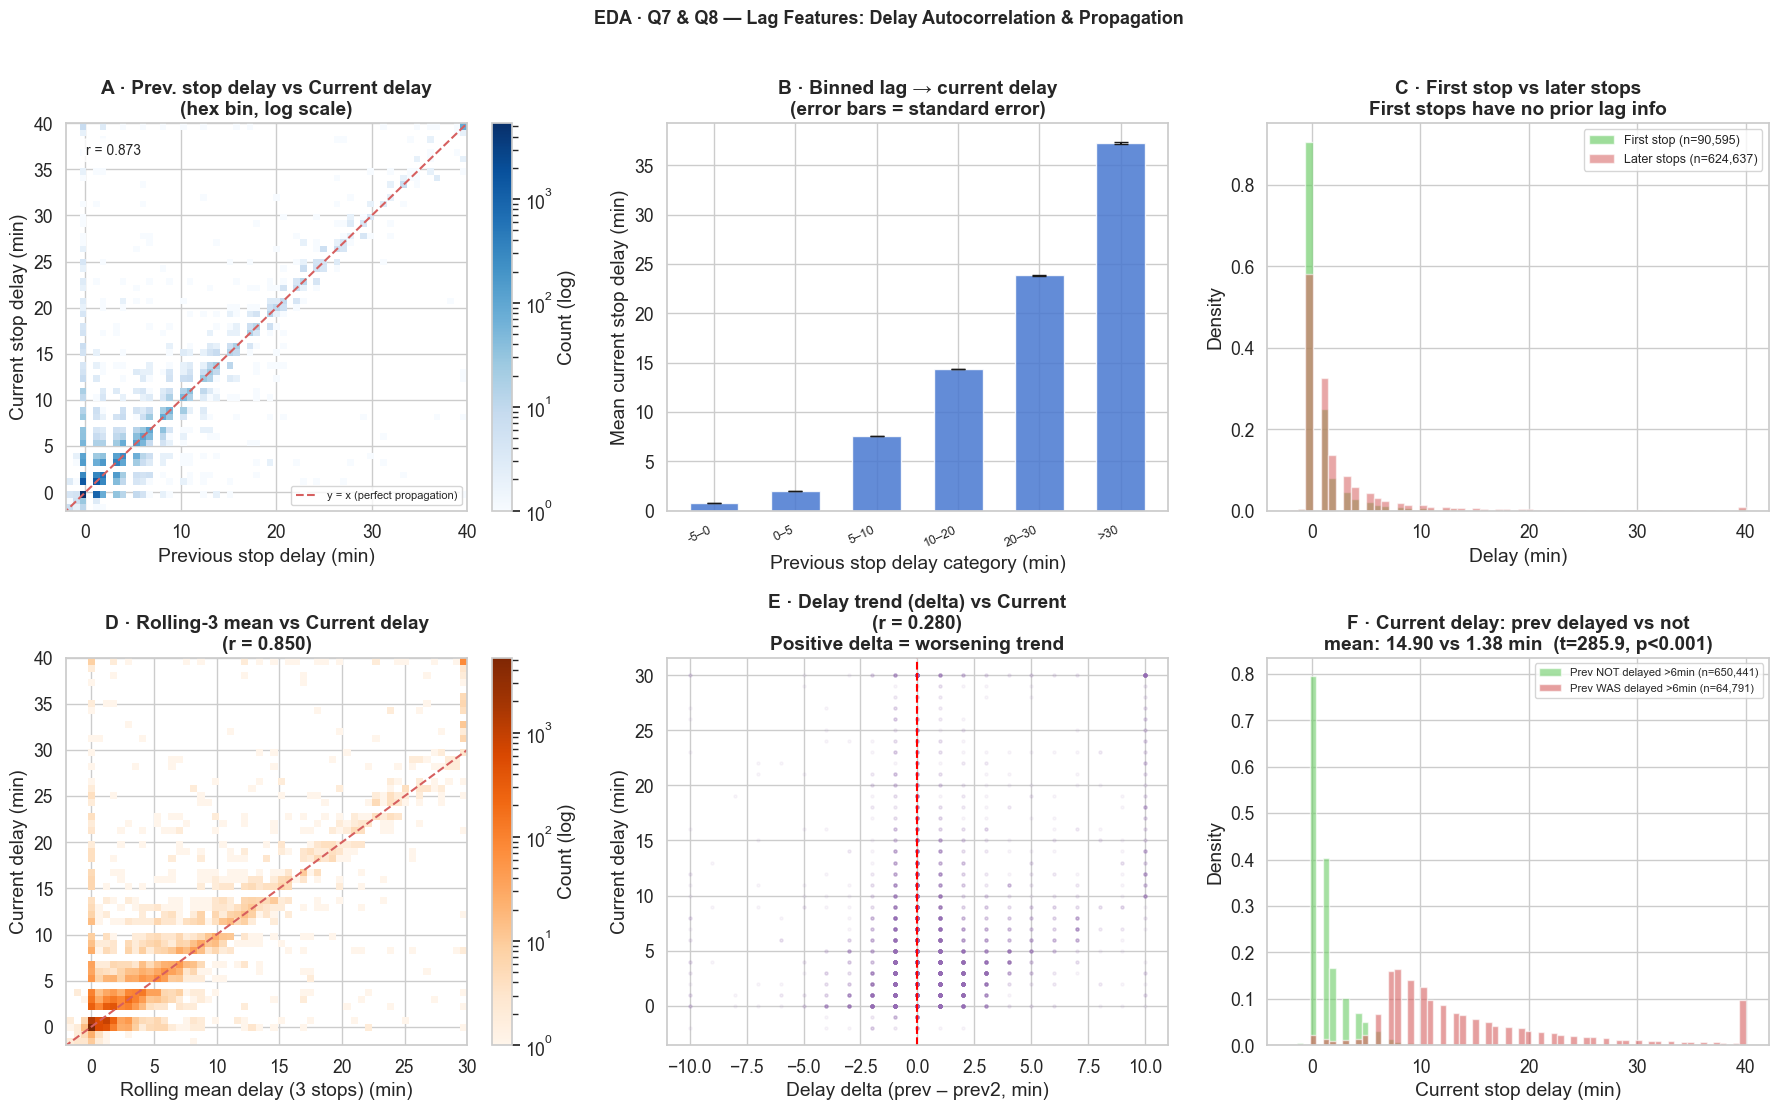

In [10]:
# ════════════════════════════════════════════════════════════
# CELL EDA-8 · Q7 — LAG FEATURE vs ACTUAL DELAY
#             Q8 — ROLLING-3 vs CURRENT DELAY
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# ── Q7: prev_stop_delay vs delay_in_min ──────────────────────
idx = np.random.choice(len(df), min(15000, len(df)), replace=False)
sample = df.iloc[idx]

ax = axes[0, 0]
h = ax.hist2d(sample["prev_stop_delay"].clip(-10, 40),
              sample["delay_in_min"].clip(-10, 40),
              bins=60, cmap="Blues", norm=mcolors.LogNorm())
plt.colorbar(h[3], ax=ax, label="Count (log)")
ax.plot([-10, 40], [-10, 40], "r--", lw=1.5, label="y = x (perfect propagation)")
ax.set_xlabel("Previous stop delay (min)")
ax.set_ylabel("Current stop delay (min)")
ax.set_title("A · Prev. stop delay vs Current delay\n(hex bin, log scale)",
             fontweight="bold")
r7, _ = pearsonr(sample["prev_stop_delay"].clip(-10,40),
                 sample["delay_in_min"].clip(-10,40))
ax.text(0.05, 0.92, f"r = {r7:.3f}", transform=ax.transAxes,
        fontsize=10, bbox=dict(boxstyle="round", fc="white", alpha=0.8))
ax.legend(fontsize=8)

# Binned means — prev_stop_delay bins
ax = axes[0, 1]
bins = [-np.inf, -5, 0, 5, 10, 20, 30, np.inf]
labels_b = ["<-5","-5–0","0–5","5–10","10–20","20–30",">30"]
df["_prev_bin"] = pd.cut(df["prev_stop_delay"], bins=bins, labels=labels_b)
bin_stats = df.groupby("_prev_bin", observed=True)["delay_in_min"].agg(
    mean="mean", se=lambda x: x.std()/np.sqrt(len(x)), n="count"
).reset_index()
ax.bar(bin_stats["_prev_bin"].astype(str), bin_stats["mean"],
       yerr=bin_stats["se"], capsize=5,
       color=PAL[0], alpha=0.85, width=0.6)
ax.set_xlabel("Previous stop delay category (min)")
ax.set_ylabel("Mean current stop delay (min)")
ax.set_title("B · Binned lag → current delay\n(error bars = standard error)",
             fontweight="bold")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=9)
df.drop(columns=["_prev_bin"], inplace=True)

# Lag ACF-style: first stop vs subsequent stops
ax = axes[0, 2]
first = df[df["is_first_stop"] == 1]["delay_in_min"]
later = df[df["is_first_stop"] == 0]["delay_in_min"]
ax.hist(first.clip(-10, 40), bins=60, density=True, alpha=0.65,
        color=PAL[2], label=f"First stop (n={len(first):,})")
ax.hist(later.clip(-10, 40), bins=60, density=True, alpha=0.55,
        color=PAL[3], label=f"Later stops (n={len(later):,})")
ax.set_xlabel("Delay (min)"); ax.set_ylabel("Density")
ax.set_title("C · First stop vs later stops\nFirst stops have no prior lag info",
             fontweight="bold")
ax.legend(fontsize=9)

# ── Q8: Rolling-3 vs current delay ───────────────────────────
ax = axes[1, 0]
h = ax.hist2d(sample["delay_rolling3"].clip(-5, 30),
              sample["delay_in_min"].clip(-5, 40),
              bins=55, cmap="Oranges", norm=mcolors.LogNorm())
plt.colorbar(h[3], ax=ax, label="Count (log)")
ax.plot([-5, 30], [-5, 30], "r--", lw=1.5)
ax.set_xlabel("Rolling mean delay (3 stops) (min)")
ax.set_ylabel("Current delay (min)")
r8, _ = pearsonr(sample["delay_rolling3"].clip(-5,30),
                 sample["delay_in_min"].clip(-5,40))
ax.set_title(f"D · Rolling-3 mean vs Current delay\n(r = {r8:.3f})", fontweight="bold")

# delta (trend) vs current delay
ax = axes[1, 1]
ax.scatter(sample["delay_delta"].clip(-10, 10),
           sample["delay_in_min"].clip(-10, 30),
           alpha=0.06, s=5, color=PAL[4])
ax.axvline(0, color="red", lw=1.5, ls="--")
ax.set_xlabel("Delay delta (prev – prev2, min)")
ax.set_ylabel("Current delay (min)")
rd, _ = pearsonr(sample["delay_delta"].clip(-10,10),
                 sample["delay_in_min"].clip(-10,30))
ax.set_title(f"E · Delay trend (delta) vs Current\n(r = {rd:.3f})\n"
             "Positive delta = worsening trend", fontweight="bold")

# Was prev stop delayed? → current
ax = axes[1, 2]
g0 = df.loc[df["prev_stop_was_delayed"]==0, "delay_in_min"]
g1 = df.loc[df["prev_stop_was_delayed"]==1, "delay_in_min"]
ax.hist(g0.clip(-10, 40), bins=70, density=True, alpha=0.6,
        color=PAL[2], label=f"Prev NOT delayed >6min (n={len(g0):,})")
ax.hist(g1.clip(-10, 40), bins=70, density=True, alpha=0.6,
        color=PAL[3], label=f"Prev WAS delayed >6min (n={len(g1):,})")
ax.set_xlabel("Current stop delay (min)"); ax.set_ylabel("Density")
print(f"  When prev stop delayed >6 min → current mean: {g1.mean():.2f} min")
print(f"  When prev stop NOT delayed    → current mean: {g0.mean():.2f} min")
t_stat, t_p = stats.ttest_ind(g1.sample(min(50000,len(g1))),
                               g0.sample(min(50000,len(g0))))
ax.set_title(f"F · Current delay: prev delayed vs not\n"
             f"mean: {g1.mean():.2f} vs {g0.mean():.2f} min  "
             f"(t={t_stat:.1f}, p<0.001)", fontweight="bold")
ax.legend(fontsize=8)

fig.suptitle("EDA · Q7 & Q8 — Lag Features: Delay Autocorrelation & Propagation",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_07_08_lag_features.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


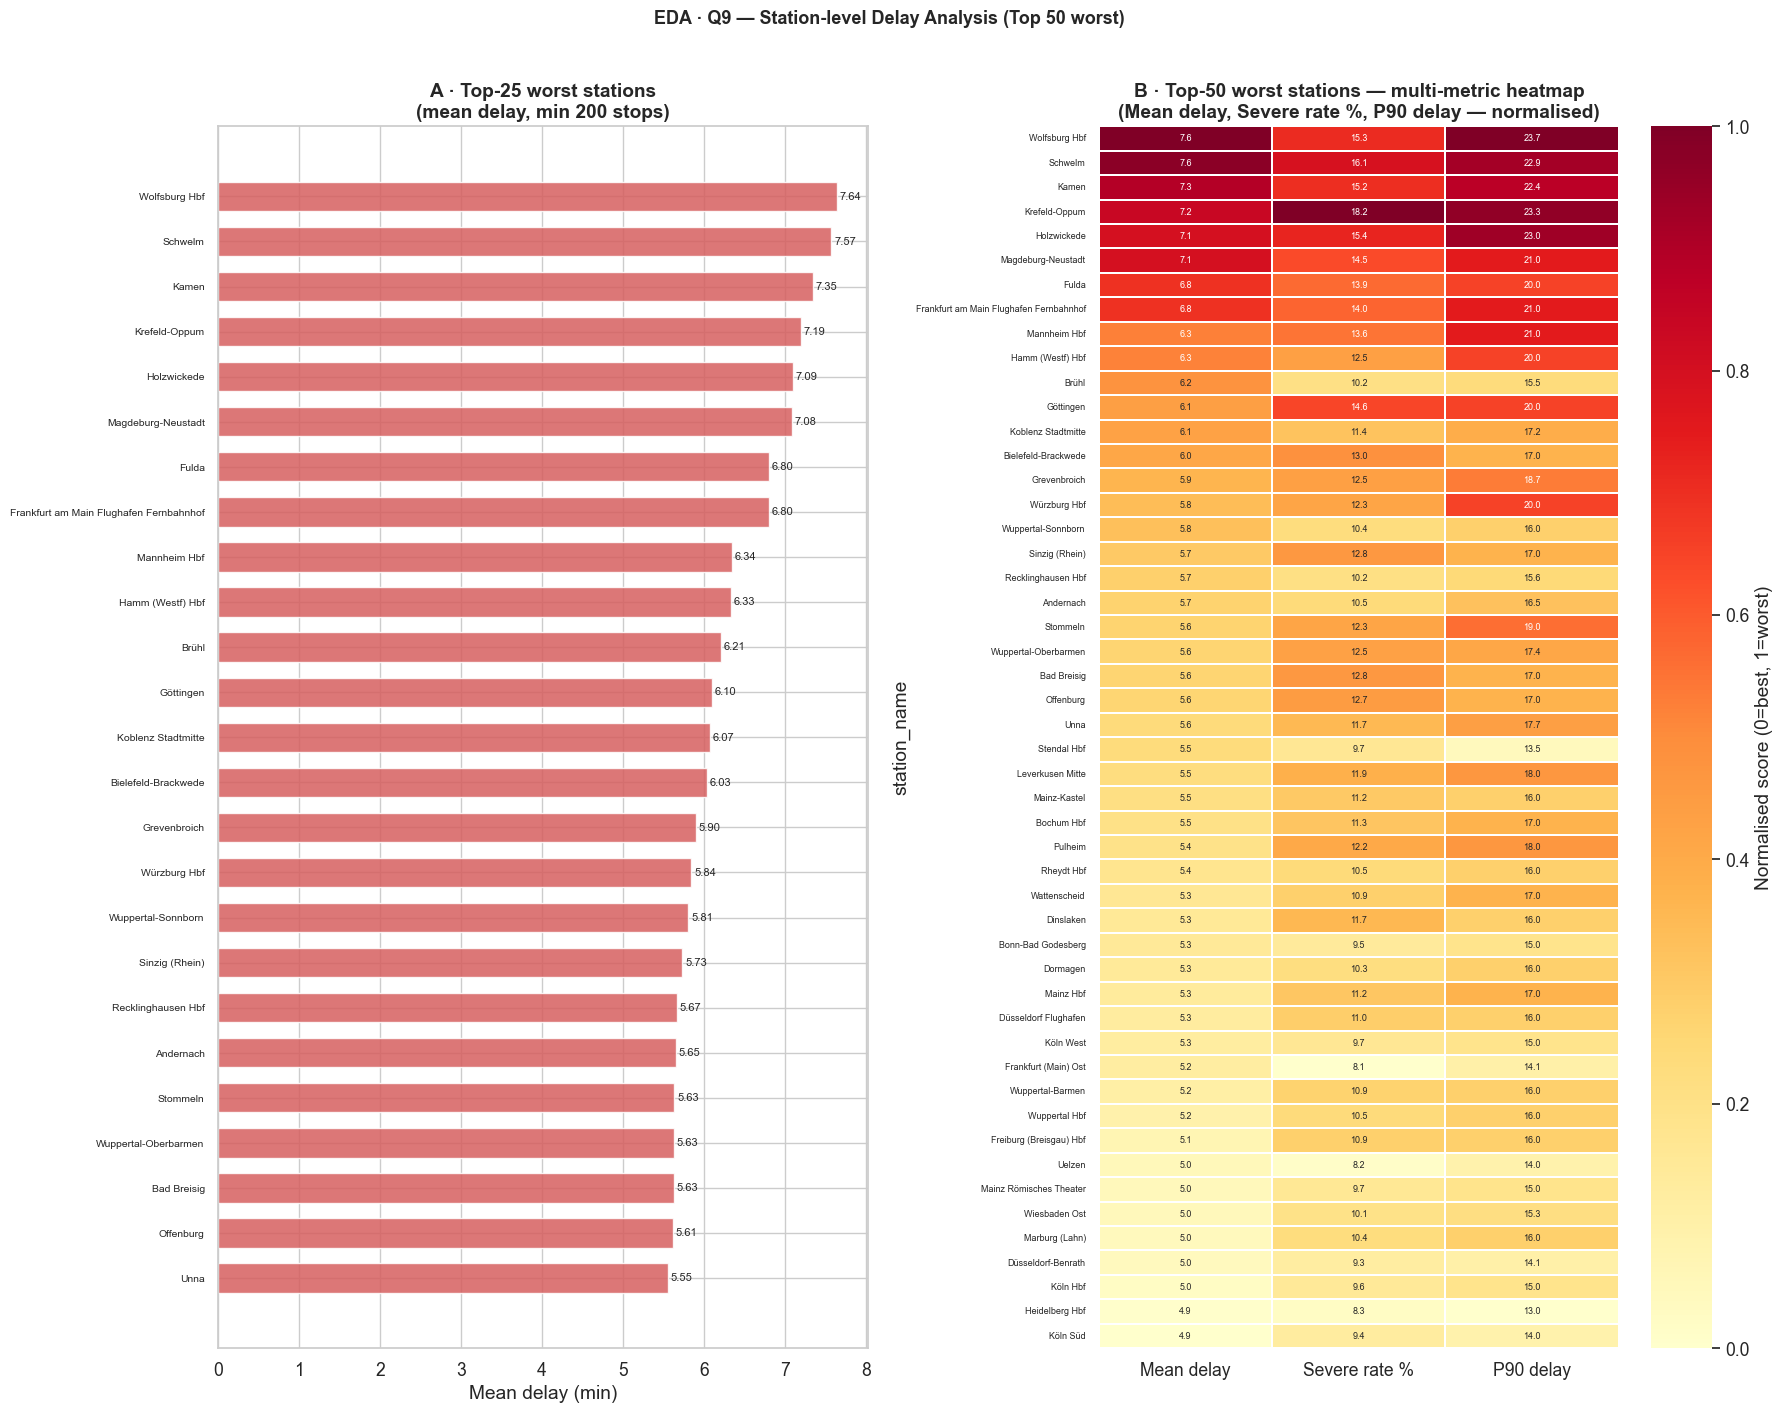


  Worst station : Wolfsburg Hbf  mean=7.64 min
  Best  station (top-200 by count): Berlin Yorckstraße/Großgörschenstraße  mean=0.41 min


In [11]:
# ════════════════════════════════════════════════════════════
# CELL EDA-9 · Q9 — TOP-50 WORST STATIONS (delay heatmap)
# ════════════════════════════════════════════════════════════

station_stats = (df.groupby("station_name")["delay_in_min"]
                 .agg(mean="mean", median="median",
                      severe=lambda x: (x>15).mean()*100,
                      n="count",
                      p90=lambda x: x.quantile(0.90))
                 .reset_index()
                 .sort_values("mean", ascending=False))

# Only show stations with >= 200 stops
station_stats = station_stats[station_stats["n"] >= 200]
top50 = station_stats.head(50).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 14))

# Bar chart of top-25 worst
ax = axes[0]
top25 = top50.head(25)
bars = ax.barh(top25["station_name"][::-1],
               top25["mean"][::-1],
               color=PAL[3], alpha=0.85, height=0.65)
ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8)
ax.set_xlabel("Mean delay (min)")
ax.set_title("A · Top-25 worst stations\n(mean delay, min 200 stops)",
             fontweight="bold")
ax.tick_params(axis="y", labelsize=7.5)

# Multi-metric heatmap for top-50
ax = axes[1]
hmap_data = top50[["station_name","mean","severe","p90"]].copy()
hmap_data = hmap_data.set_index("station_name")
hmap_data.columns = ["Mean delay", "Severe rate %", "P90 delay"]

# Normalise each column 0–1 for heatmap
hmap_norm = (hmap_data - hmap_data.min()) / (hmap_data.max() - hmap_data.min())
sns.heatmap(hmap_norm, ax=ax, cmap="YlOrRd",
            annot=hmap_data.round(1), fmt=".1f",
            annot_kws={"size": 6.5}, linewidths=0.2,
            cbar_kws={"label": "Normalised score (0=best, 1=worst)"})
ax.set_title("B · Top-50 worst stations — multi-metric heatmap\n"
             "(Mean delay, Severe rate %, P90 delay — normalised)",
             fontweight="bold")
ax.tick_params(axis="y", labelsize=6.5)

fig.suptitle("EDA · Q9 — Station-level Delay Analysis (Top 50 worst)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_09_station_heatmap.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

print(f"\n  Worst station : {top50.iloc[0]['station_name']}  "
      f"mean={top50.iloc[0]['mean']:.2f} min")
print(f"  Best  station (top-200 by count): "
      f"{station_stats.tail(1)['station_name'].values[0]}  "
      f"mean={station_stats.tail(1)['mean'].values[0]:.2f} min")


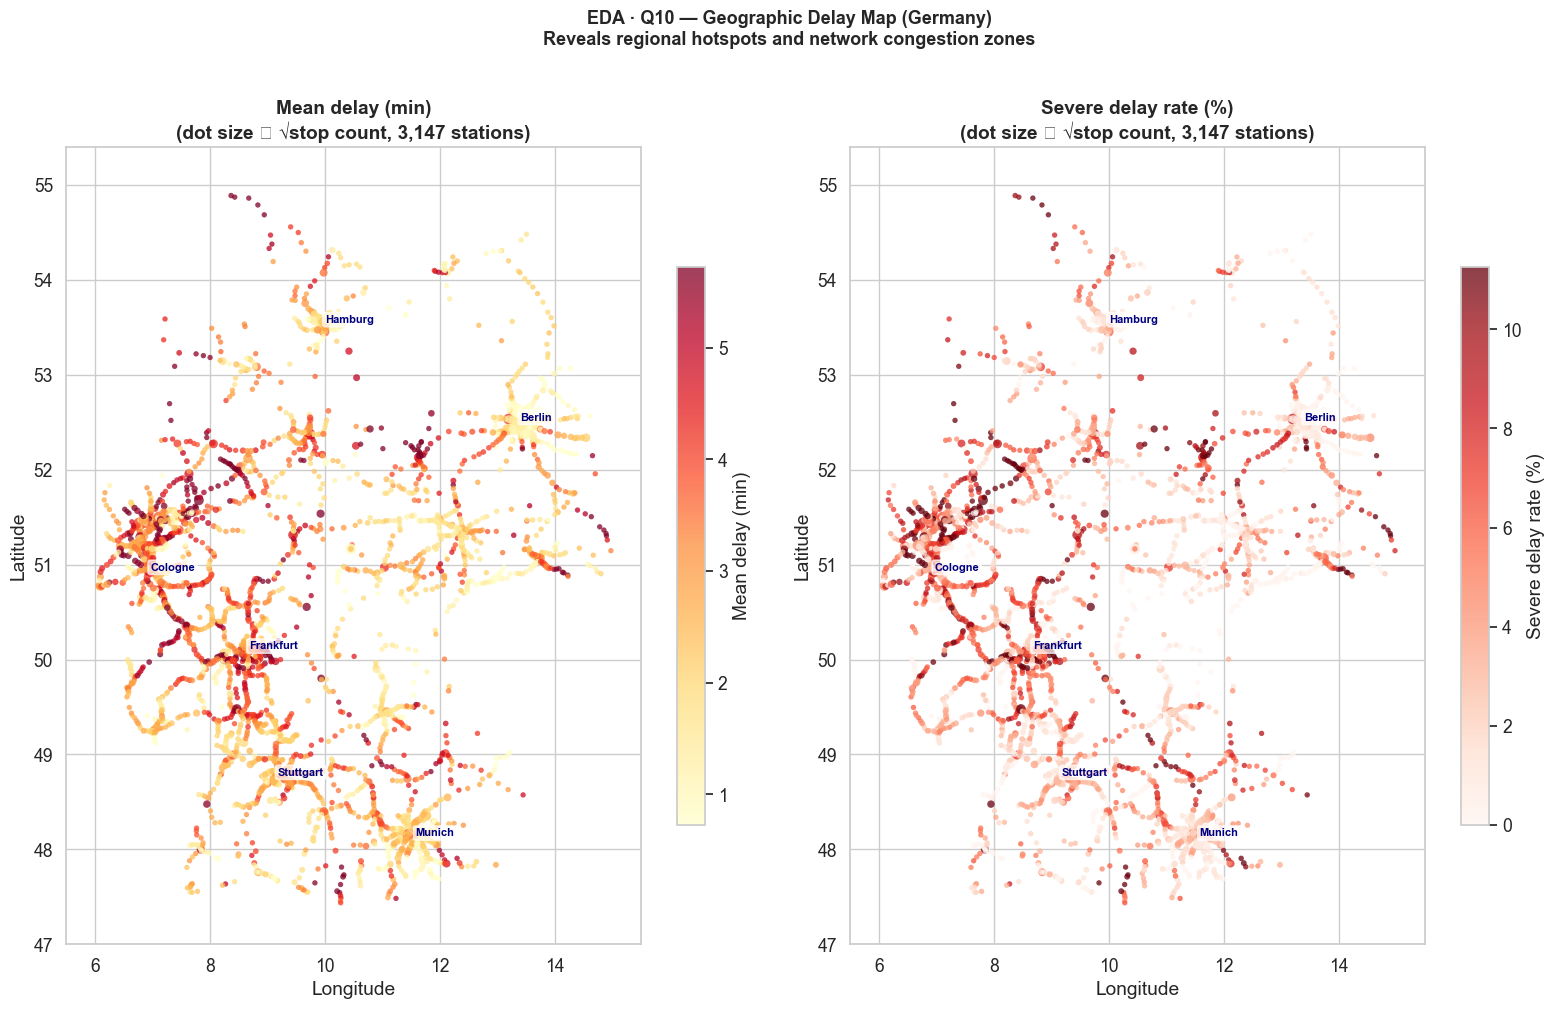

  North Germany (lat≥52) mean delay: 2.42 min
  South Germany (lat<51) mean delay: 2.84 min


In [12]:
# ════════════════════════════════════════════════════════════
# CELL EDA-10 · Q10 — GEOGRAPHIC DELAY MAP (lat / lon scatter)
# ════════════════════════════════════════════════════════════

# Aggregate to station level to avoid overplotting
geo_stats = (df.groupby(["station_name","lat","lon"])["delay_in_min"]
             .agg(mean="mean",
                  severe=lambda x: (x>15).mean()*100,
                  n="count")
             .reset_index())

geo_stats = geo_stats[geo_stats["n"] >= 50].copy()

# Filter to Germany bounding box
geo_stats = geo_stats[
    geo_stats["lat"].between(47.2, 55.2) &
    geo_stats["lon"].between(5.8, 15.1)
]

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

for ax, col, title, cmap in zip(
        axes,
        ["mean", "severe"],
        ["Mean delay (min)", "Severe delay rate (%)"],
        ["YlOrRd", "Reds"]):

    sc = ax.scatter(
        geo_stats["lon"], geo_stats["lat"],
        c=geo_stats[col],
        s=np.clip(np.sqrt(geo_stats["n"]) * 1.5, 15, 120),
        cmap=cmap, alpha=0.75,
        edgecolors="none",
        vmin=geo_stats[col].quantile(0.05),
        vmax=geo_stats[col].quantile(0.95),
    )
    plt.colorbar(sc, ax=ax, label=title, shrink=0.7)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title(f"{title}\n(dot size ∝ √stop count, "
                 f"{len(geo_stats):,} stations)", fontweight="bold")
    ax.set_xlim(5.5, 15.5); ax.set_ylim(47.0, 55.4)
    # Add approximate city labels
    for city, la, lo in [("Berlin",52.52,13.40),("Munich",48.14,11.58),
                          ("Hamburg",53.55,10.00),("Cologne",50.94,6.96),
                          ("Frankfurt",50.11,8.68),("Stuttgart",48.78,9.18)]:
        ax.annotate(city, (lo, la), fontsize=8, color="navy",
                    fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

fig.suptitle("EDA · Q10 — Geographic Delay Map (Germany)\n"
             "Reveals regional hotspots and network congestion zones",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_10_geo_delay_map.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

# North vs South comparison
north = geo_stats[geo_stats["lat"] >= 52]["mean"].mean()
south = geo_stats[geo_stats["lat"] <  51]["mean"].mean()
print(f"  North Germany (lat≥52) mean delay: {north:.2f} min")
print(f"  South Germany (lat<51) mean delay: {south:.2f} min")


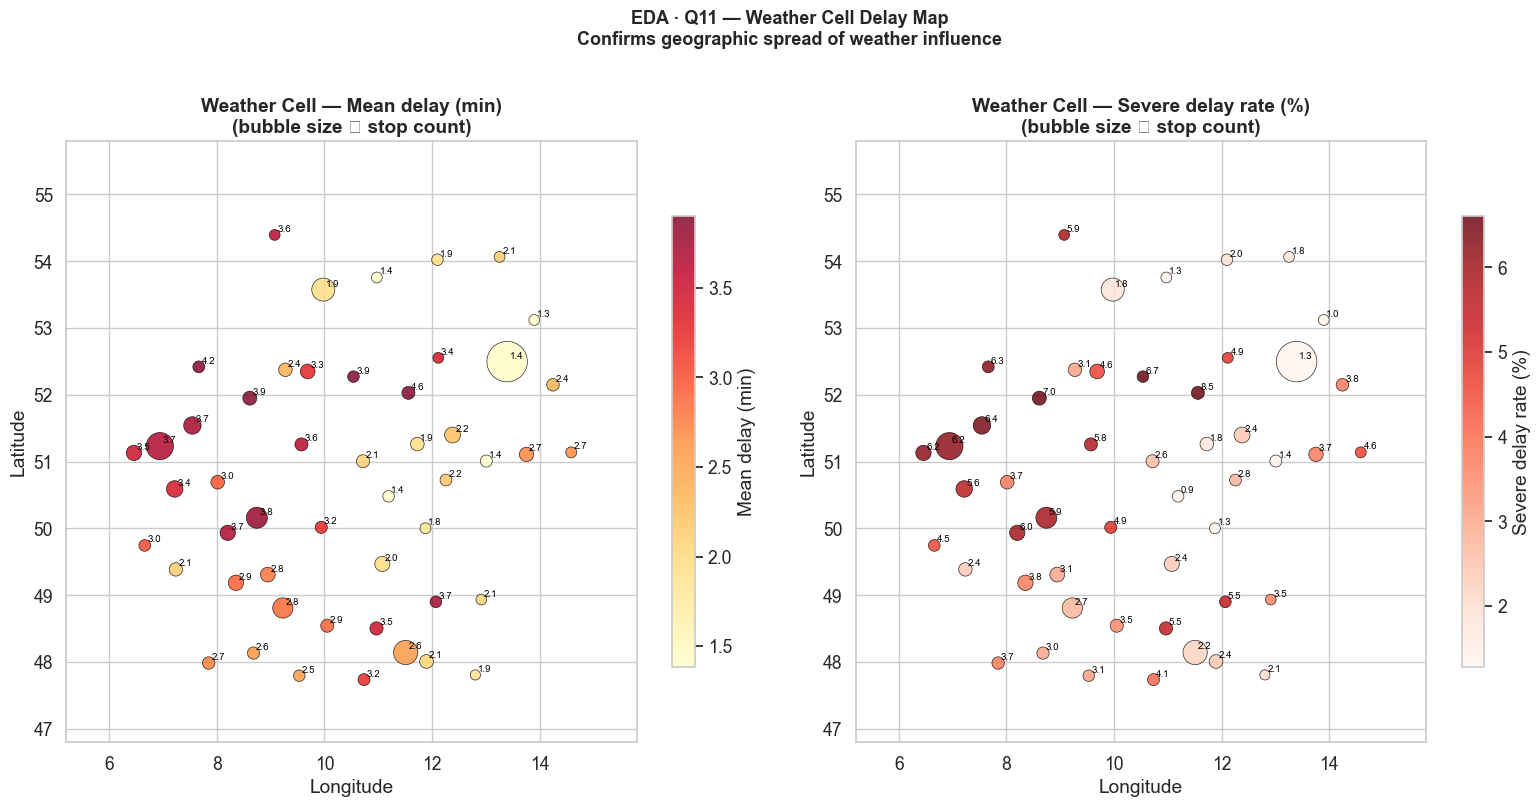

In [13]:
# ════════════════════════════════════════════════════════════
# CELL EDA-11 · Q11 — WEATHER CELL DELAY MAP
# ════════════════════════════════════════════════════════════

with open(OUTPUT_DIR / "config.json") as f:
    cfg2 = json.load(f)

cell_delay = (df.groupby("weather_cell")["delay_in_min"]
              .agg(mean="mean",
                   severe=lambda x: (x>15).mean()*100,
                   n="count")
              .reset_index())

# Get cell centroids from station-level lat/lon means
cell_centres = (df.groupby("weather_cell")[["lat","lon"]].mean().reset_index()
                .rename(columns={"lat":"cell_lat","lon":"cell_lon"}))

cell_df = cell_delay.merge(cell_centres, on="weather_cell")
cell_df = cell_df[
    cell_df["cell_lat"].between(47.0, 55.5) &
    cell_df["cell_lon"].between(5.5, 15.5)
]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, col, title, cmap in zip(
        axes,
        ["mean", "severe"],
        ["Mean delay (min)", "Severe delay rate (%)"],
        ["YlOrRd", "Reds"]):
    sc = ax.scatter(cell_df["cell_lon"], cell_df["cell_lat"],
                    c=cell_df[col], s=cell_df["n"]/cell_df["n"].max()*800+50,
                    cmap=cmap, alpha=0.82, edgecolors="black", lw=0.5,
                    vmin=cell_df[col].quantile(0.05),
                    vmax=cell_df[col].quantile(0.95))
    plt.colorbar(sc, ax=ax, label=title, shrink=0.75)
    for _, row in cell_df.iterrows():
        ax.annotate(f"{row[col]:.1f}",
                    (row["cell_lon"]+0.05, row["cell_lat"]+0.05),
                    fontsize=7, color="black")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title(f"Weather Cell — {title}\n"
                 "(bubble size ∝ stop count)", fontweight="bold")
    ax.set_xlim(5.2, 15.8); ax.set_ylim(46.8, 55.8)

fig.suptitle("EDA · Q11 — Weather Cell Delay Map\n"
             "Confirms geographic spread of weather influence",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_11_weather_cell_map.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


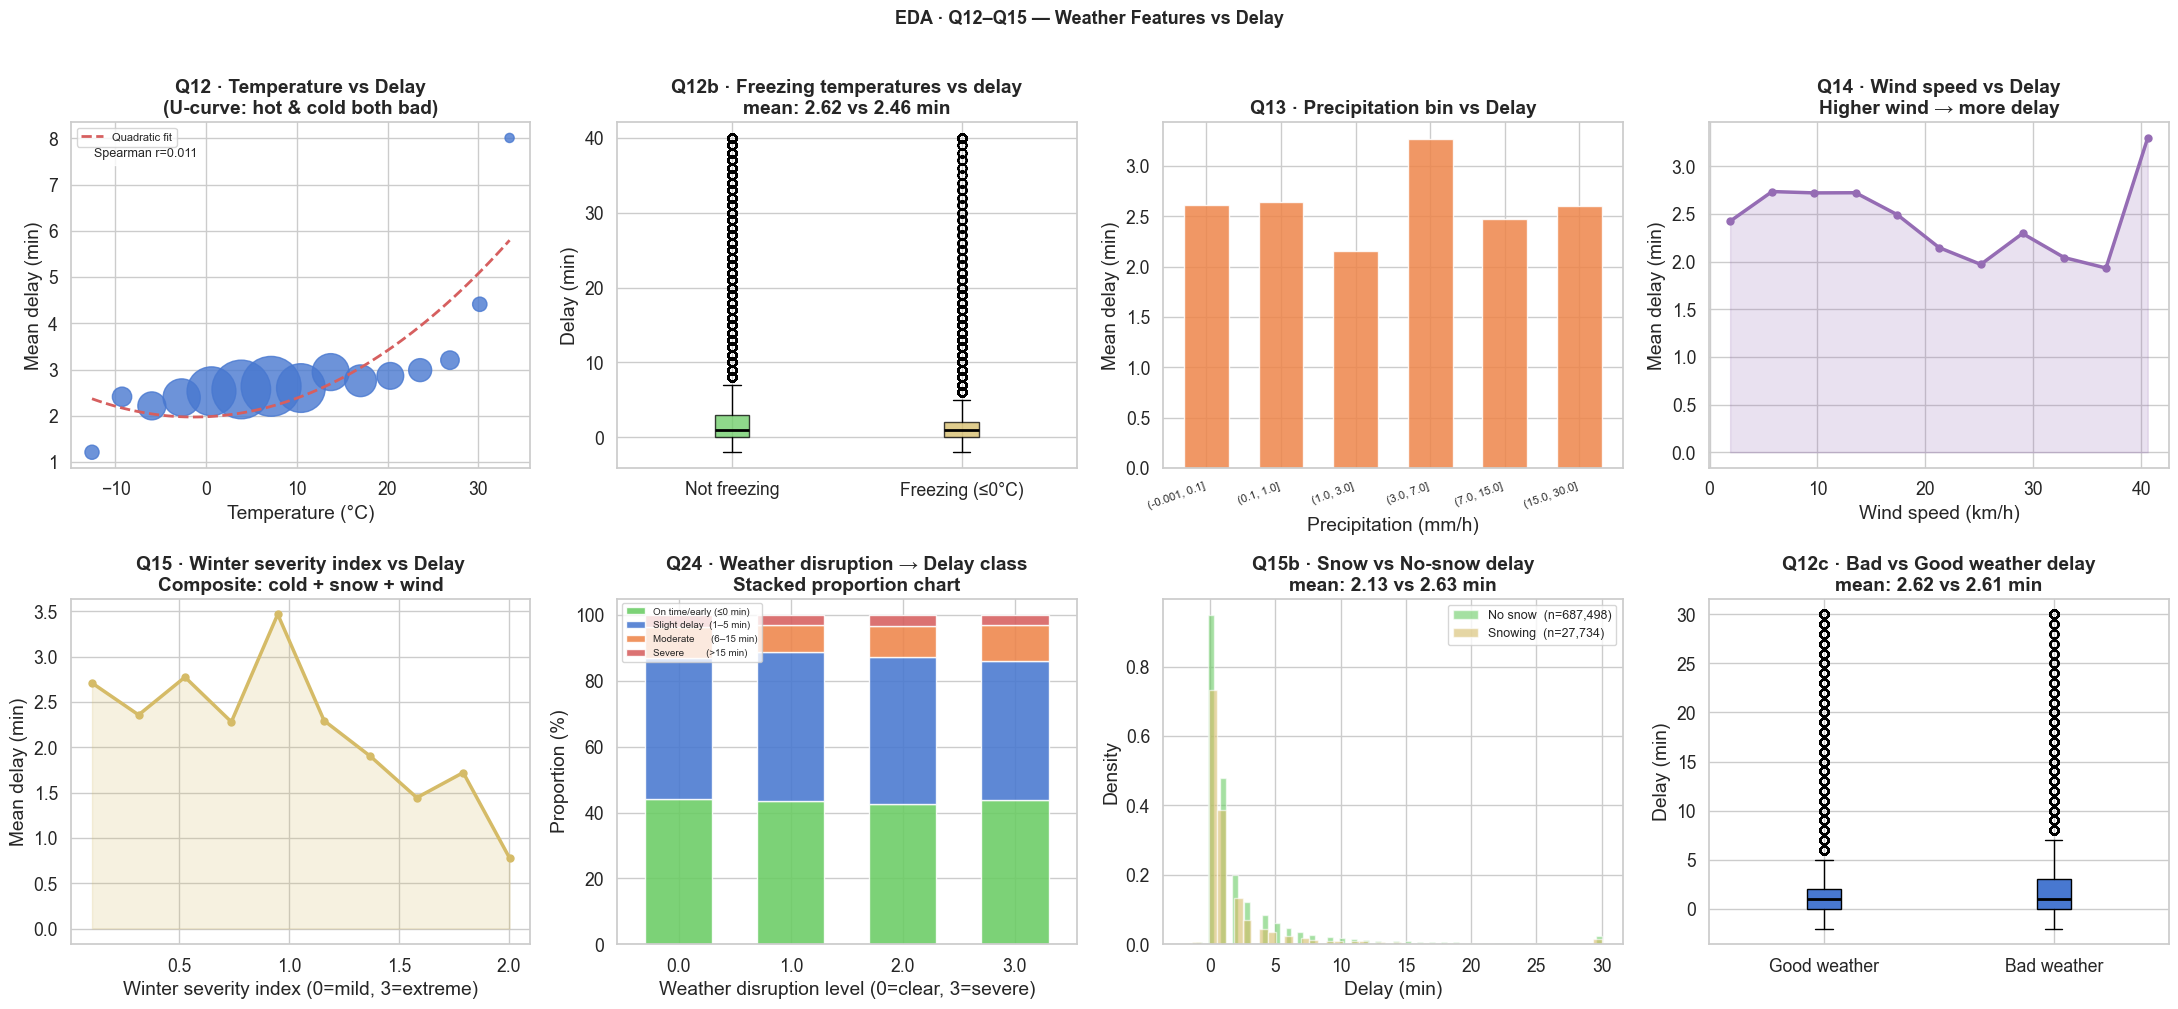

In [14]:
# ════════════════════════════════════════════════════════════
# CELL EDA-12 · Q12–Q15 — WEATHER FEATURES vs DELAY
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 4, figsize=(22, 10))

# ── Q12: Temperature vs delay ─────────────────────────────────
if "temp" in df.columns:
    ax = axes[0, 0]
    temp_bins = pd.cut(df["temp"], bins=15)
    tb = df.groupby(temp_bins, observed=True)["delay_in_min"].mean()
    tc = df.groupby(temp_bins, observed=True)["delay_in_min"].count()
    mask_t = tc >= 50
    midpoints_t = [iv.mid for iv in tb[mask_t].index]
    ax.scatter(midpoints_t, tb[mask_t].values,
               s=np.sqrt(tc[mask_t].values)*4, color=PAL[0], alpha=0.8)
    z = np.polyfit(midpoints_t, tb[mask_t].values, 2)
    p_fit = np.poly1d(z)
    xs = np.linspace(min(midpoints_t), max(midpoints_t), 100)
    ax.plot(xs, p_fit(xs), "r--", lw=2, label="Quadratic fit")
    ax.set_xlabel("Temperature (°C)"); ax.set_ylabel("Mean delay (min)")
    ax.set_title("Q12 · Temperature vs Delay\n(U-curve: hot & cold both bad)",
                 fontweight="bold")
    ax.legend(fontsize=8)
    rt, _ = spearmanr(df["temp"].dropna(), df["delay_in_min"])
    ax.text(0.05, 0.9, f"Spearman r={rt:.3f}", transform=ax.transAxes,
            fontsize=9, bbox=dict(fc="white", alpha=0.8))

# is_freezing
if "is_freezing" in df.columns:
    ax = axes[0, 1]
    g_frz = [df.loc[df["is_freezing"]==0,"delay_in_min"],
              df.loc[df["is_freezing"]==1,"delay_in_min"]]
    bp = ax.boxplot([g.clip(-5,40).values for g in g_frz],
                    patch_artist=True,
                    medianprops=dict(color="black",lw=2))
    bp["boxes"][0].set_facecolor(PAL[2]); bp["boxes"][0].set_alpha(0.75)
    bp["boxes"][1].set_facecolor(PAL[8]); bp["boxes"][1].set_alpha(0.75)
    ax.set_xticklabels(["Not freezing", "Freezing (≤0°C)"])
    ax.set_ylabel("Delay (min)")
    ax.set_title(f"Q12b · Freezing temperatures vs delay\n"
                 f"mean: {g_frz[0].mean():.2f} vs {g_frz[1].mean():.2f} min",
                 fontweight="bold")

# ── Q13: Precipitation vs delay ──────────────────────────────
if "prcp" in df.columns:
    ax = axes[0, 2]
    prcp_bins = pd.cut(df["prcp"].clip(0,30), bins=[0,.1,1,3,7,15,30],
                       include_lowest=True)
    pb = df.groupby(prcp_bins, observed=True)["delay_in_min"].mean()
    pc = df.groupby(prcp_bins, observed=True).size()
    ax.bar(range(len(pb)), pb.values, color=PAL[1], alpha=0.85, width=0.6)
    ax.set_xticks(range(len(pb)))
    ax.set_xticklabels([str(iv) for iv in pb.index], rotation=20, ha="right", fontsize=8)
    ax.set_xlabel("Precipitation (mm/h)"); ax.set_ylabel("Mean delay (min)")
    ax.set_title("Q13 · Precipitation bin vs Delay", fontweight="bold")

# ── Q14: Wind speed vs delay ──────────────────────────────────
if "wspd" in df.columns:
    ax = axes[0, 3]
    wind_bins = pd.cut(df["wspd"].clip(0, 100), bins=12)
    wb = df.groupby(wind_bins, observed=True)["delay_in_min"].mean()
    wc = df.groupby(wind_bins, observed=True).size()
    mask_w = wc >= 50
    midpoints_w = [iv.mid for iv in wb[mask_w].index]
    ax.plot(midpoints_w, wb[mask_w].values, color=PAL[4], lw=2.5,
            marker="o", ms=5)
    ax.fill_between(midpoints_w, wb[mask_w].values, alpha=0.2, color=PAL[4])
    ax.set_xlabel("Wind speed (km/h)"); ax.set_ylabel("Mean delay (min)")
    ax.set_title("Q14 · Wind speed vs Delay\nHigher wind → more delay",
                 fontweight="bold")

# ── Q15: Winter severity vs delay ────────────────────────────
if "winter_severity" in df.columns:
    ax = axes[1, 0]
    ws_bins = pd.cut(df["winter_severity"].clip(0, 3), bins=10)
    wsb = df.groupby(ws_bins, observed=True)["delay_in_min"].mean()
    wsc = df.groupby(ws_bins, observed=True).size()
    mask_ws = wsc >= 50
    midpoints_ws = [iv.mid for iv in wsb[mask_ws].index]
    ax.plot(midpoints_ws, wsb[mask_ws].values, color=PAL[8], lw=2.5, marker="o", ms=5)
    ax.fill_between(midpoints_ws, wsb[mask_ws].values, alpha=0.2, color=PAL[8])
    ax.set_xlabel("Winter severity index (0=mild, 3=extreme)")
    ax.set_ylabel("Mean delay (min)")
    ax.set_title("Q15 · Winter severity index vs Delay\nComposite: cold + snow + wind",
                 fontweight="bold")

# Weather disruption vs delay class
if "weather_disruption" in df.columns:
    ax = axes[1, 1]
    wd_cls = (df.groupby(["weather_disruption","delay_class"])
               .size().unstack(fill_value=0))
    wd_cls = wd_cls.div(wd_cls.sum(axis=1), axis=0) * 100
    wd_cls.plot(kind="bar", ax=ax, stacked=True,
                color=CLASS_COLORS, alpha=0.88, width=0.6)
    ax.set_xlabel("Weather disruption level (0=clear, 3=severe)")
    ax.set_ylabel("Proportion (%)")
    ax.set_title("Q24 · Weather disruption → Delay class\n"
                 "Stacked proportion chart", fontweight="bold")
    ax.legend([CLASS_LABELS[k] for k in [0,1,2,3]], fontsize=7,
              loc="upper left")
    plt.setp(ax.get_xticklabels(), rotation=0)

# Snow vs delay
if "snow" in df.columns:
    ax = axes[1, 2]
    no_snow = df.loc[df["snow"] == 0, "delay_in_min"]
    snow    = df.loc[df["snow"] > 0,  "delay_in_min"]
    ax.hist(no_snow.clip(-5,30), bins=70, density=True, alpha=0.6,
            color=PAL[2], label=f"No snow  (n={len(no_snow):,})")
    ax.hist(snow.clip(-5,30),    bins=50, density=True, alpha=0.6,
            color=PAL[8], label=f"Snowing  (n={len(snow):,})")
    ax.set_xlabel("Delay (min)"); ax.set_ylabel("Density")
    ax.set_title(f"Q15b · Snow vs No-snow delay\n"
                 f"mean: {snow.mean():.2f} vs {no_snow.mean():.2f} min",
                 fontweight="bold")
    ax.legend(fontsize=9)

# Bad weather combined
if "is_bad_weather" in df.columns:
    ax = axes[1, 3]
    good = df.loc[df["is_bad_weather"]==0,"delay_in_min"]
    bad  = df.loc[df["is_bad_weather"]==1,"delay_in_min"]
    ax.boxplot([good.clip(-5,30).values, bad.clip(-5,30).values],
               patch_artist=True,
               medianprops=dict(color="black",lw=2))
    ax.set_xticklabels(["Good weather","Bad weather"])
    ax.set_ylabel("Delay (min)")
    ax.set_title(f"Q12c · Bad vs Good weather delay\n"
                 f"mean: {bad.mean():.2f} vs {good.mean():.2f} min",
                 fontweight="bold")

fig.suptitle("EDA · Q12–Q15 — Weather Features vs Delay",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_12_15_weather_vs_delay.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


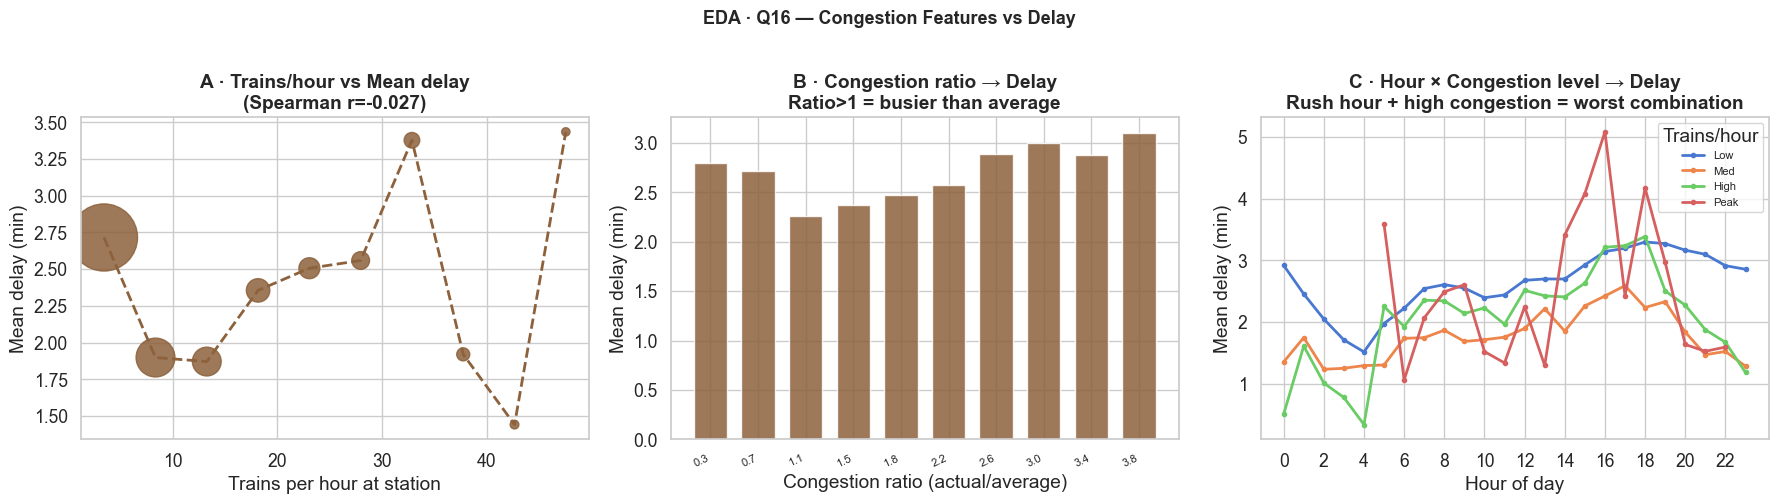

In [15]:
# ════════════════════════════════════════════════════════════
# CELL EDA-13 · Q16 — CONGESTION vs DELAY
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Trains per hour vs mean delay
ax = axes[0]
cong_bins = pd.cut(df["trains_this_hour"].clip(0, 60), bins=10)
cb = df.groupby(cong_bins, observed=True)["delay_in_min"].mean()
cc = df.groupby(cong_bins, observed=True).size()
midpoints_c = [iv.mid for iv in cb.index]
ax.scatter(midpoints_c, cb.values, s=np.sqrt(cc.values)*3,
           color=PAL[5], alpha=0.85)
ax.plot(midpoints_c, cb.values, color=PAL[5], lw=2, ls="--")
rc, _ = spearmanr(df["trains_this_hour"], df["delay_in_min"])
ax.set_xlabel("Trains per hour at station")
ax.set_ylabel("Mean delay (min)")
ax.set_title(f"A · Trains/hour vs Mean delay\n"
             f"(Spearman r={rc:.3f})", fontweight="bold")

# Congestion ratio vs delay
ax = axes[1]
crat_bins = pd.cut(df["congestion_ratio"].clip(0, 4), bins=10)
crb = df.groupby(crat_bins, observed=True)["delay_in_min"].mean()
crc = df.groupby(crat_bins, observed=True).size()
midpoints_cr = [iv.mid for iv in crb.index]
bars = ax.bar(range(len(crb)), crb.values, color=PAL[5], alpha=0.85, width=0.7)
ax.set_xticks(range(len(crb)))
ax.set_xticklabels([f"{m:.1f}" for m in midpoints_cr],
                   rotation=25, ha="right", fontsize=8)
ax.set_xlabel("Congestion ratio (actual/average)")
ax.set_ylabel("Mean delay (min)")
ax.set_title("B · Congestion ratio → Delay\n"
             "Ratio>1 = busier than average", fontweight="bold")

# Hour of day × congestion interaction
ax = axes[2]
pivot_cong = df.pivot_table(
    index="hour", columns=pd.cut(df["trains_this_hour"].clip(0,50),
                                  bins=[0,5,15,30,50], labels=["Low","Med","High","Peak"]),
    values="delay_in_min", aggfunc="mean", observed=True
)
for col in pivot_cong.columns:
    ax.plot(pivot_cong.index, pivot_cong[col], lw=2, marker="o", ms=3, label=str(col))
ax.set_xlabel("Hour of day"); ax.set_ylabel("Mean delay (min)")
ax.set_title("C · Hour × Congestion level → Delay\n"
             "Rush hour + high congestion = worst combination",
             fontweight="bold")
ax.legend(title="Trains/hour", fontsize=8)
ax.set_xticks(range(0, 24, 2))

fig.suptitle("EDA · Q16 — Congestion Features vs Delay",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_16_congestion_vs_delay.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


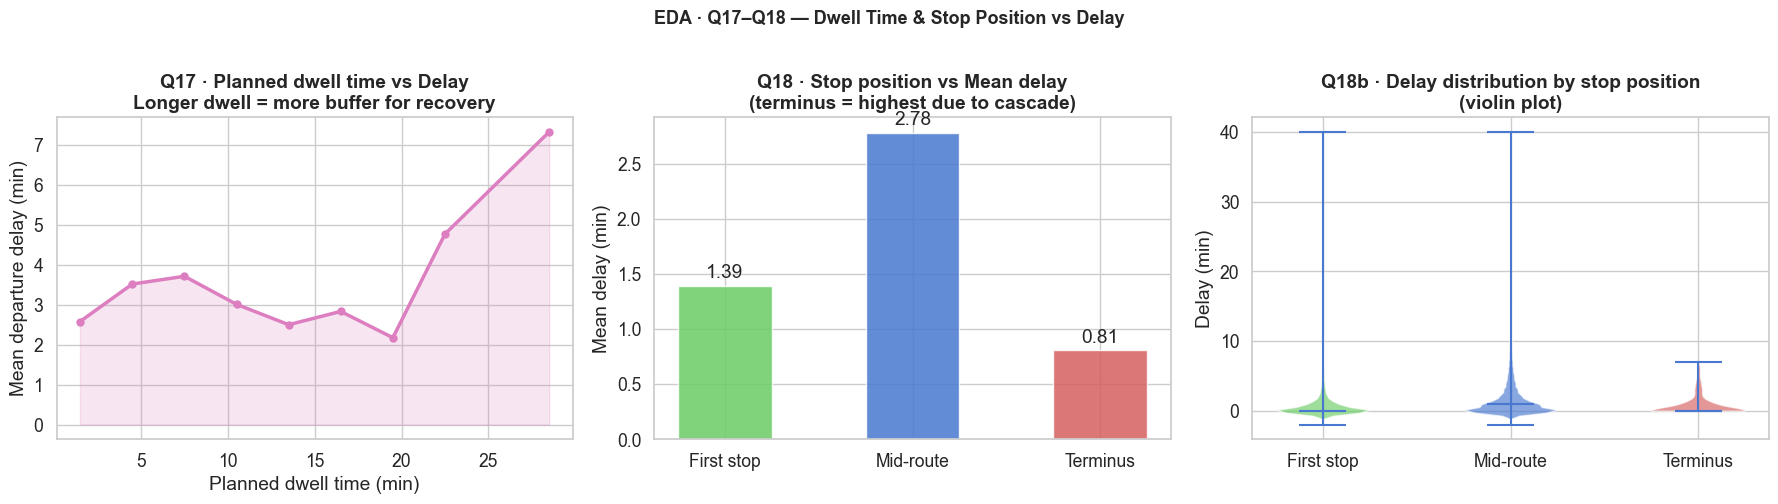

In [16]:
# ════════════════════════════════════════════════════════════
# CELL EDA-14 · Q17 — PLANNED DWELL TIME vs DELAY
#              Q18 — FIRST / MID / TERMINUS
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Q17: dwell time vs delay
ax = axes[0]
dwell_bins = pd.cut(df["planned_dwell_min"].clip(0, 30), bins=10)
db_mean = df.groupby(dwell_bins, observed=True)["delay_in_min"].mean()
db_n    = df.groupby(dwell_bins, observed=True).size()
mask_d  = db_n >= 100
midpoints_d = [iv.mid for iv in db_mean[mask_d].index]
ax.plot(midpoints_d, db_mean[mask_d].values,
        color=PAL[6], lw=2.5, marker="o", ms=5)
ax.fill_between(midpoints_d, db_mean[mask_d].values, alpha=0.2, color=PAL[6])
ax.set_xlabel("Planned dwell time (min)")
ax.set_ylabel("Mean departure delay (min)")
ax.set_title("Q17 · Planned dwell time vs Delay\n"
             "Longer dwell = more buffer for recovery", fontweight="bold")

# Q18: stop position category
ax = axes[1]
df["_stop_pos"] = "Mid-route"
df.loc[df["is_first_stop"]==1, "_stop_pos"] = "First stop"
df.loc[df["is_terminus"]==1,   "_stop_pos"] = "Terminus"
pos_stats = df.groupby("_stop_pos")["delay_in_min"].agg(
    mean="mean", median="median", severe=lambda x: (x>15).mean()*100
).reset_index()
colors_pos = [PAL[2], PAL[0], PAL[3]]
bars = ax.bar(pos_stats["_stop_pos"], pos_stats["mean"],
              color=colors_pos, alpha=0.85, width=0.5)
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.set_ylabel("Mean delay (min)")
ax.set_title("Q18 · Stop position vs Mean delay\n"
             "(terminus = highest due to cascade)",
             fontweight="bold")

# Violin: distribution by position
ax = axes[2]
pos_data = {p: df.loc[df["_stop_pos"]==p, "delay_in_min"].clip(-10, 40).values
            for p in ["First stop","Mid-route","Terminus"]}
parts = ax.violinplot(list(pos_data.values()), positions=[0,1,2],
                      showmedians=True, showextrema=True)
for body, color in zip(parts["bodies"], colors_pos):
    body.set_facecolor(color); body.set_alpha(0.65)
ax.set_xticks([0,1,2]); ax.set_xticklabels(list(pos_data.keys()))
ax.set_ylabel("Delay (min)")
ax.set_title("Q18b · Delay distribution by stop position\n"
             "(violin plot)", fontweight="bold")
df.drop(columns=["_stop_pos"], inplace=True)

fig.suptitle("EDA · Q17–Q18 — Dwell Time & Stop Position vs Delay",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_17_18_dwell_position.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


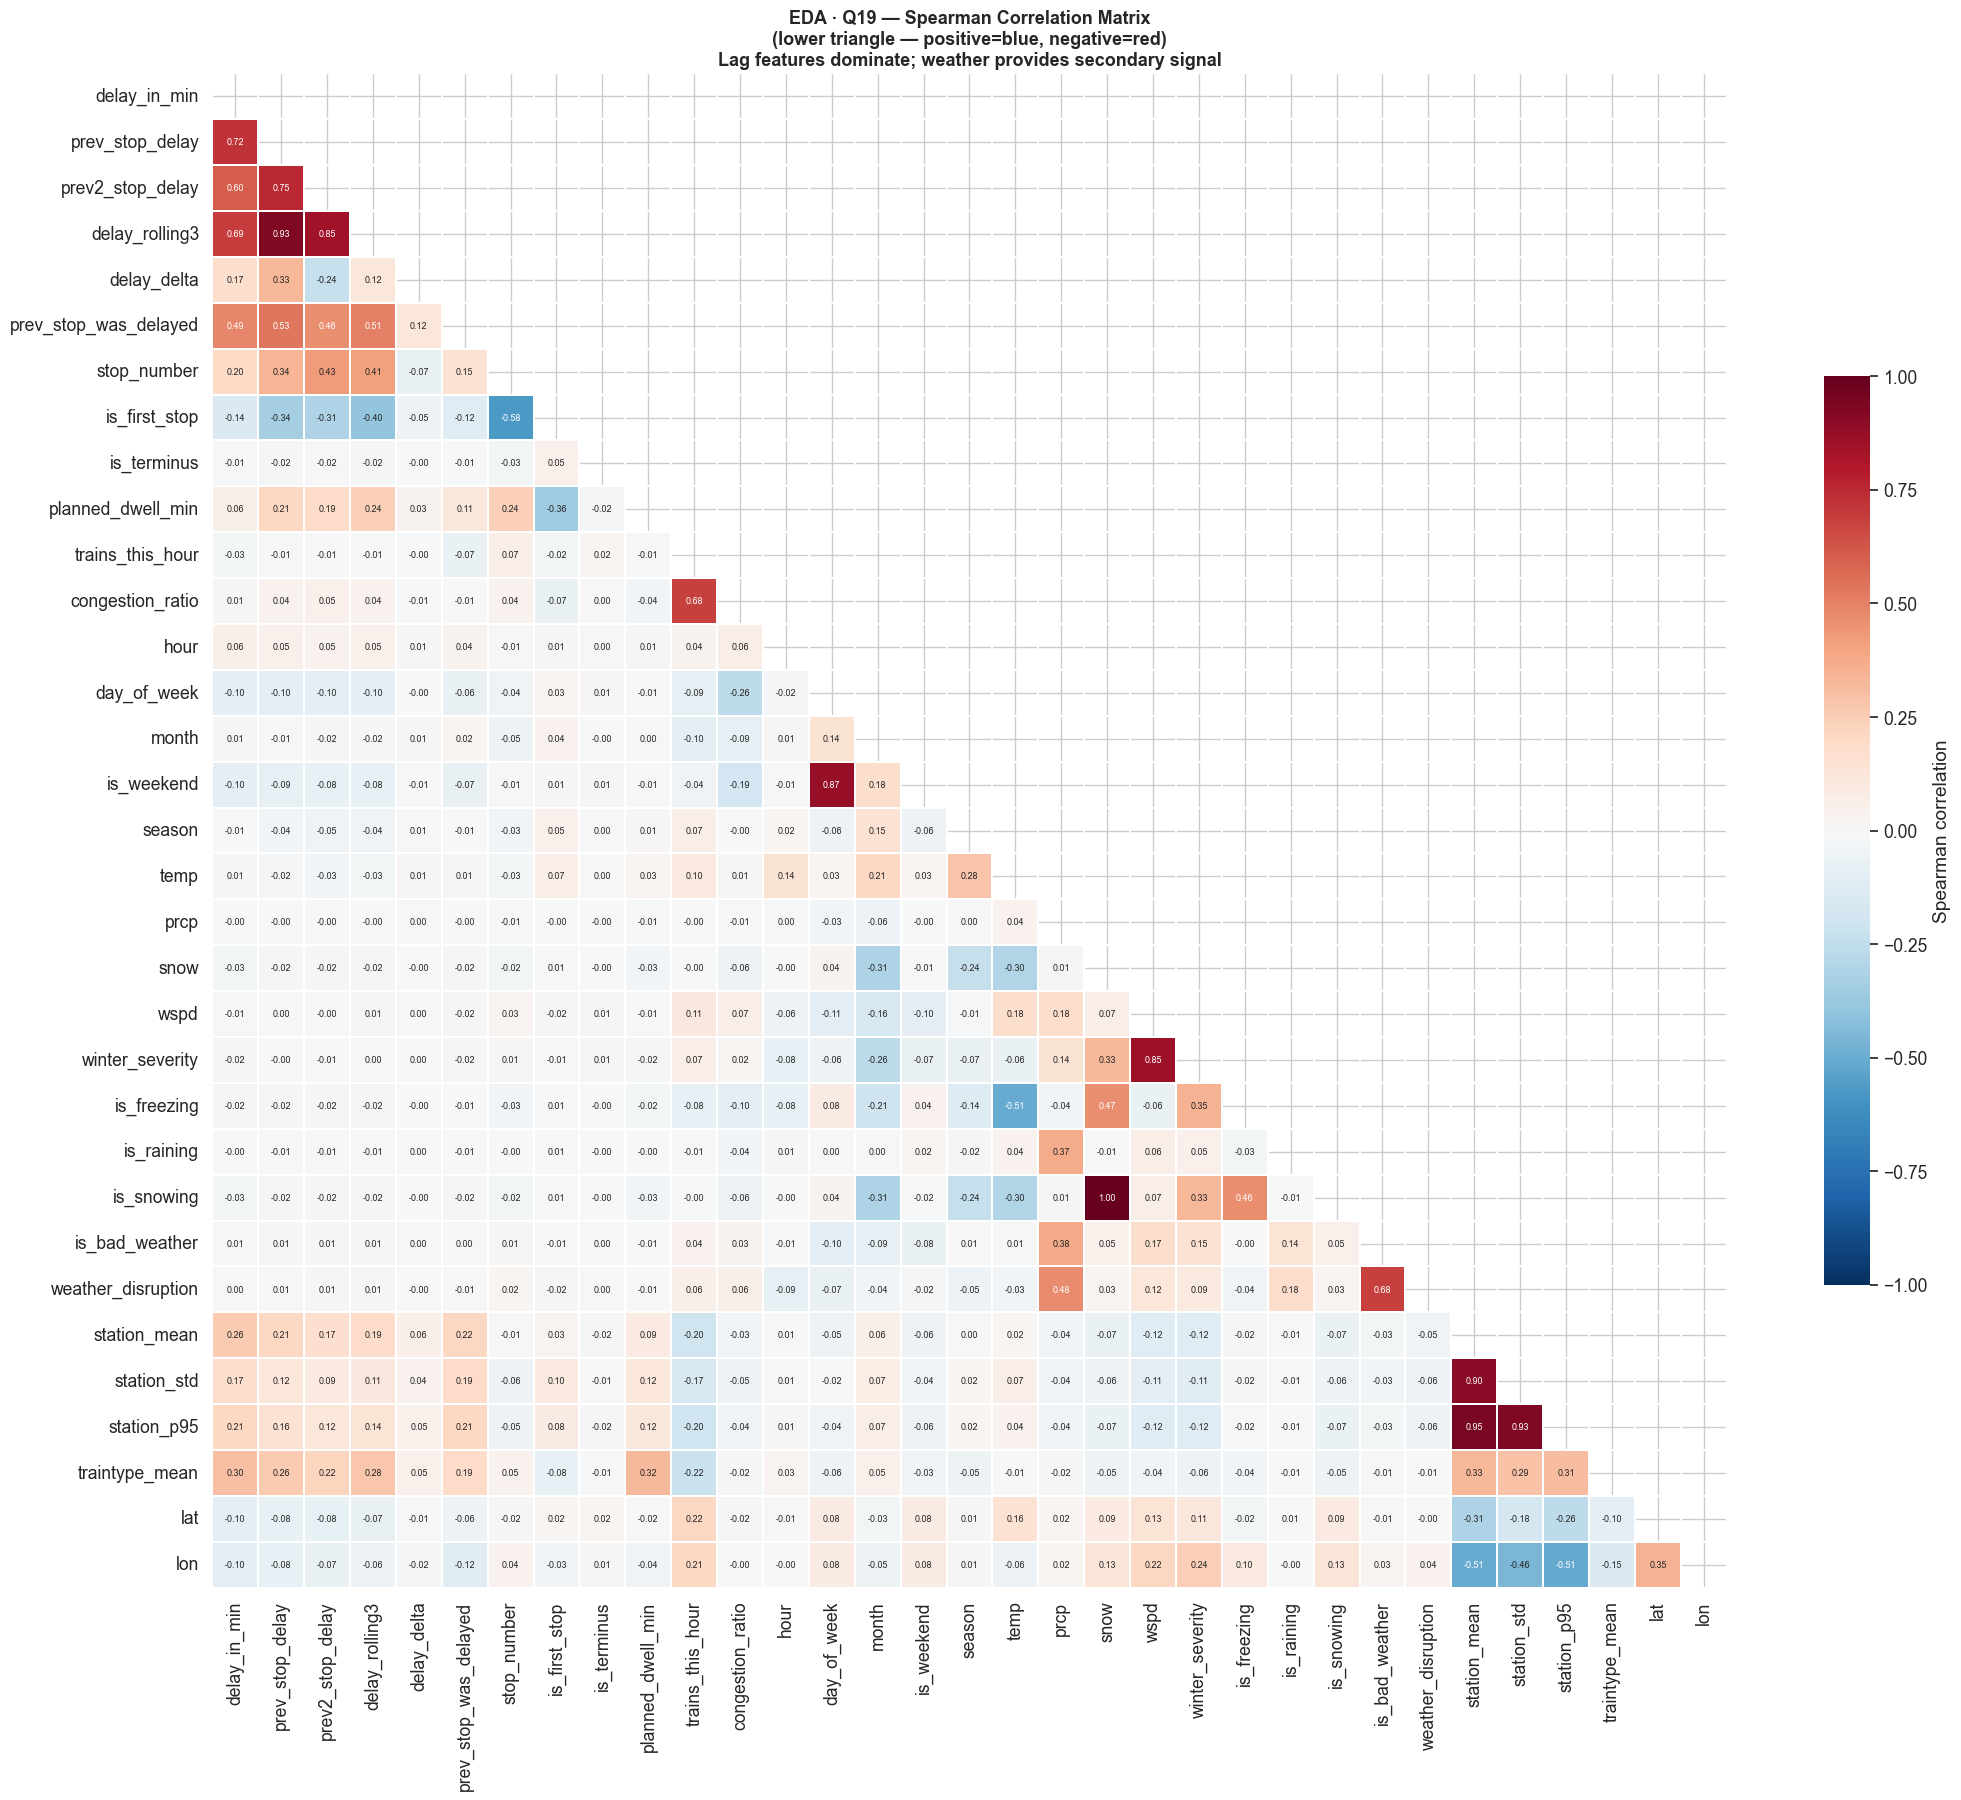

  Top-20 features by |Spearman r| with delay_in_min:
    prev_stop_delay                    : +0.724  █████████████████████
    delay_rolling3                     : +0.694  ████████████████████
    prev2_stop_delay                   : +0.602  ██████████████████
    prev_stop_was_delayed              : +0.490  ██████████████
    traintype_mean                     : +0.297  ████████
    station_mean                       : +0.261  ███████
    station_p95                        : +0.207  ██████
    stop_number                        : +0.199  █████
    station_std                        : +0.175  █████
    delay_delta                        : +0.174  █████
    is_first_stop                      : -0.145  ████
    lon                                : -0.101  ███
    day_of_week                        : -0.099  ██
    lat                                : -0.096  ██
    is_weekend                         : -0.096  ██
    planned_dwell_min                  : +0.061  █
    hour                

In [17]:
# ════════════════════════════════════════════════════════════
# CELL EDA-15 · Q19 — CORRELATION HEATMAP
# ════════════════════════════════════════════════════════════

FEATURES_TREE   = cfg["FEATURES_TREE"]
FEATURES_LINEAR = cfg["FEATURES_LINEAR"]

numeric_feats = [f for f in FEATURES_TREE if f in df.columns
                 and df[f].dtype in ["float32","float64","int8","int16","int32","int64"]]

# Keep most informative subset for readability
key_feats = [
    "delay_in_min",
    "prev_stop_delay", "prev2_stop_delay", "delay_rolling3", "delay_delta",
    "prev_stop_was_delayed",
    "stop_number", "is_first_stop", "is_terminus", "planned_dwell_min",
    "trains_this_hour", "congestion_ratio",
    "hour", "day_of_week", "month", "is_weekend", "season",
    "temp", "prcp", "snow", "wspd", "winter_severity",
    "is_freezing", "is_raining", "is_snowing", "is_bad_weather",
    "weather_disruption", "station_mean", "station_std",
    "station_p95", "traintype_mean",
    "lat", "lon",
]
key_feats = [f for f in key_feats if f in df.columns]

corr_df = df[key_feats].dropna().sample(min(100000, len(df))).corr(method="spearman")

fig, ax = plt.subplots(figsize=(22, 18))
mask_upper = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, ax=ax, mask=mask_upper,
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 6.5},
            linewidths=0.25, square=True,
            cbar_kws={"shrink": 0.6, "label": "Spearman correlation"})
ax.set_title("EDA · Q19 — Spearman Correlation Matrix\n"
             "(lower triangle — positive=blue, negative=red)\n"
             "Lag features dominate; weather provides secondary signal",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_19_correlation_heatmap.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

# Print top correlations with target
target_corr = corr_df["delay_in_min"].drop("delay_in_min").sort_values(key=abs, ascending=False)
print("  Top-20 features by |Spearman r| with delay_in_min:")
for feat, val in target_corr.head(20).items():
    bar = "█" * int(abs(val) * 30)
    print(f"    {feat:35s}: {val:+.3f}  {bar}")


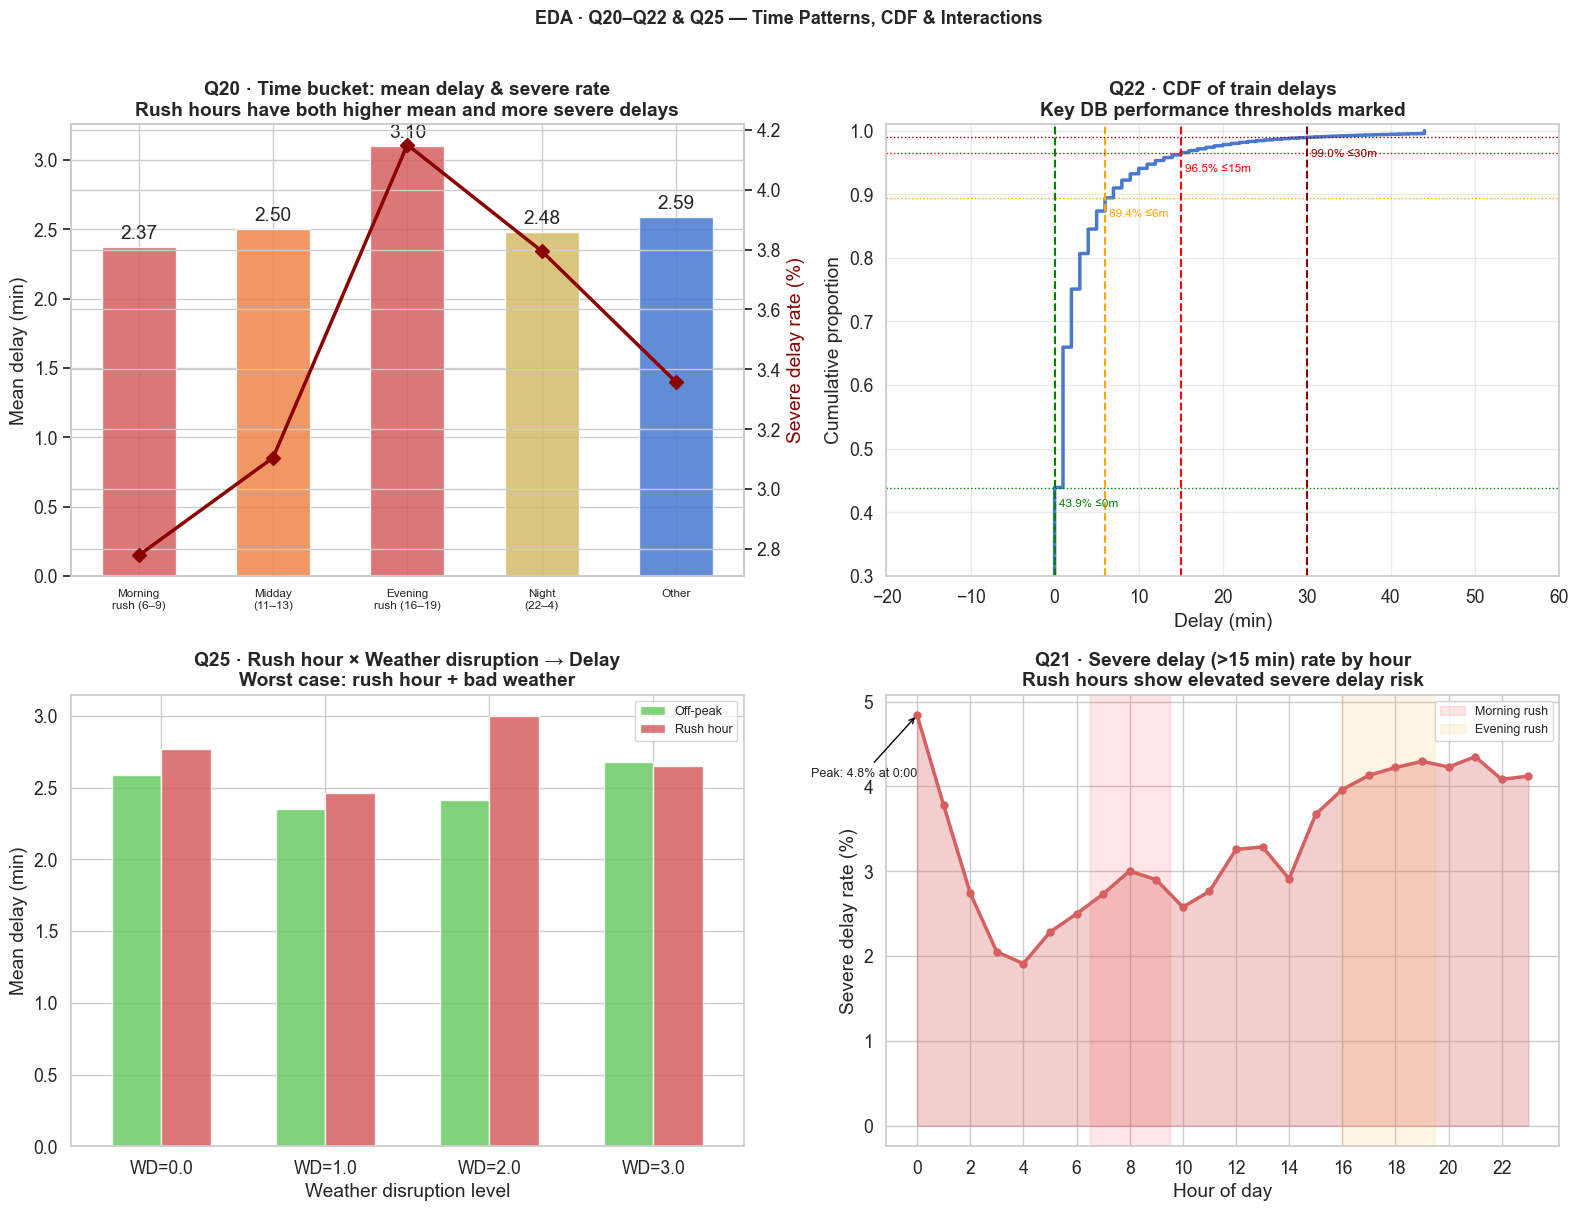

In [18]:
# ════════════════════════════════════════════════════════════
# CELL EDA-16 · Q20 — TIME BUCKET / Q21 — SEVERE RATE BY HOUR
#              Q22 — CDF  /  Q25 — WEATHER × RUSH INTERACTION
# ════════════════════════════════════════════════════════════

TB_LABELS = {0:"Morning\nrush (6–9)",1:"Midday\n(11–13)",
             2:"Evening\nrush (16–19)",3:"Night\n(22–4)",4:"Other"}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Q20: time bucket vs delay
ax = axes[0, 0]
tb_stats = df.groupby("time_bucket")["delay_in_min"].agg(
    mean="mean", severe=lambda x: (x>15).mean()*100, n="count"
).reset_index()
bars = ax.bar([TB_LABELS[t] for t in tb_stats["time_bucket"]],
              tb_stats["mean"],
              color=[PAL[3],PAL[1],PAL[3],PAL[8],PAL[0]],
              alpha=0.85, width=0.55)
ax.bar_label(bars, fmt="%.2f", padding=3)
ax2b = ax.twinx()
ax2b.plot([TB_LABELS[t] for t in tb_stats["time_bucket"]],
          tb_stats["severe"], color="darkred", lw=2.5,
          marker="D", ms=7, label="Severe rate %")
ax2b.set_ylabel("Severe delay rate (%)", color="darkred")
ax.set_ylabel("Mean delay (min)")
ax.set_title("Q20 · Time bucket: mean delay & severe rate\n"
             "Rush hours have both higher mean and more severe delays",
             fontweight="bold")
plt.setp(ax.get_xticklabels(), fontsize=8.5)

# Q22: CDF of absolute error coverage
ax = axes[0, 1]
sorted_d = np.sort(df["delay_in_min"].values)
cdf_vals = np.arange(1, len(sorted_d)+1) / len(sorted_d)
ax.plot(sorted_d, cdf_vals, lw=2.5, color=PAL[0])
for threshold, color, label in [
        (0, "green",  "On time (≤0 min)"),
        (6, "orange", "DB standard (≤6 min)"),
        (15,"red",    "Not severe (≤15 min)"),
        (30,"darkred","Not very late (≤30 min)")]:
    pct = (df["delay_in_min"] <= threshold).mean() * 100
    ax.axvline(threshold, color=color, lw=1.5, ls="--")
    ax.axhline(pct/100, color=color, lw=1, ls=":")
    ax.annotate(f"{pct:.1f}% ≤{threshold}m",
                (threshold + 0.5, pct/100 - 0.03),
                fontsize=8.5, color=color)
ax.set_xlim(-20, 60); ax.set_ylim(0.3, 1.01)
ax.set_xlabel("Delay (min)"); ax.set_ylabel("Cumulative proportion")
ax.set_title("Q22 · CDF of train delays\nKey DB performance thresholds marked",
             fontweight="bold")
ax.grid(True, alpha=0.4)

# Q25: Weather × Rush hour interaction
ax = axes[1, 0]
df["_is_rush"] = df["time_bucket"].isin([0, 2]).astype(int)
interact = df.groupby(["_is_rush","weather_disruption"])["delay_in_min"].mean().unstack()
interact.index = ["Off-peak","Rush hour"]
interact.columns = [f"WD={c}" for c in interact.columns]
interact.T.plot(kind="bar", ax=ax, color=[PAL[2],PAL[3]],
                alpha=0.85, width=0.6)
ax.set_xlabel("Weather disruption level")
ax.set_ylabel("Mean delay (min)")
ax.set_title("Q25 · Rush hour × Weather disruption → Delay\n"
             "Worst case: rush hour + bad weather",
             fontweight="bold")
plt.setp(ax.get_xticklabels(), rotation=0)
ax.legend(fontsize=9)
df.drop(columns=["_is_rush"], inplace=True)

# Q21: Severe delay rate by hour — filled area
ax = axes[1, 1]
sev_by_hour = (df.groupby("hour")["is_severe"].mean() * 100)
ax.fill_between(sev_by_hour.index, sev_by_hour.values,
                alpha=0.3, color=PAL[3])
ax.plot(sev_by_hour.index, sev_by_hour.values,
        color=PAL[3], lw=2.5, marker="o", ms=5)
ax.axvspan(6.5, 9.5,  alpha=0.1, color="red",    label="Morning rush")
ax.axvspan(16,  19.5, alpha=0.1, color="orange",  label="Evening rush")
peak_sev = sev_by_hour.idxmax()
ax.annotate(f"Peak: {sev_by_hour.max():.1f}% at {peak_sev}:00",
            xy=(peak_sev, sev_by_hour.max()),
            xytext=(peak_sev-4, sev_by_hour.max()*0.85),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=9)
ax.set_xlabel("Hour of day"); ax.set_ylabel("Severe delay rate (%)")
ax.set_title("Q21 · Severe delay (>15 min) rate by hour\n"
             "Rush hours show elevated severe delay risk",
             fontweight="bold")
ax.legend(fontsize=9); ax.set_xticks(range(0,24,2))

fig.suptitle("EDA · Q20–Q22 & Q25 — Time Patterns, CDF & Interactions",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_20_25_time_cdf_interaction.png",
            dpi=FIG_DPI, bbox_inches="tight")
plt.show()


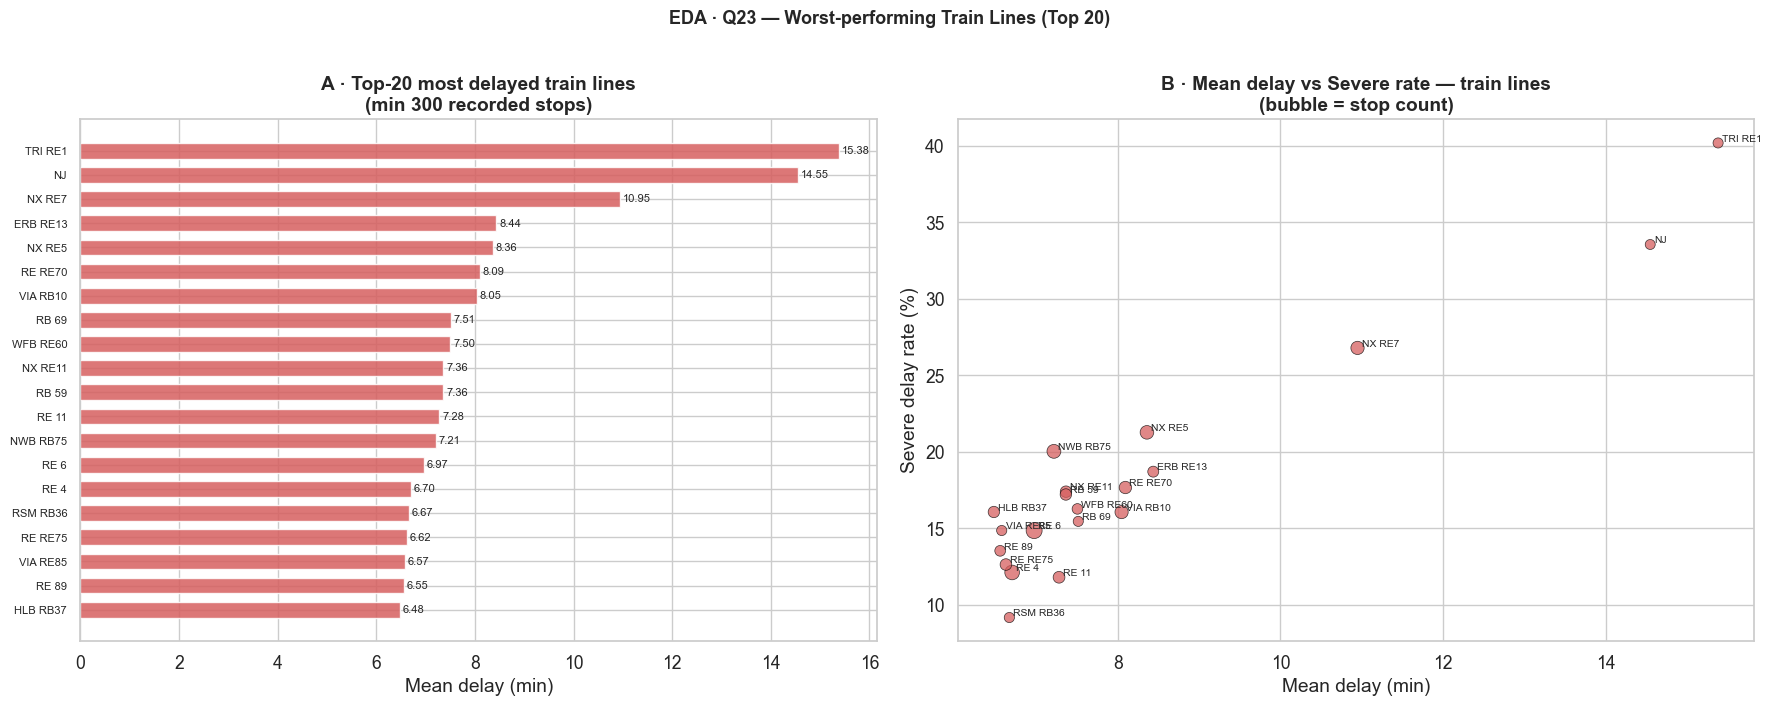

In [19]:
# ════════════════════════════════════════════════════════════
# CELL EDA-17 · Q23 — TOP-20 WORST TRAIN LINES
# ════════════════════════════════════════════════════════════

line_stats = (df.groupby("train_name")["delay_in_min"]
              .agg(mean="mean",
                   severe=lambda x: (x>15).mean()*100,
                   n="count")
              .reset_index()
              .query("n >= 300")
              .sort_values("mean", ascending=False)
              .head(20))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
bars = ax.barh(line_stats["train_name"][::-1],
               line_stats["mean"][::-1],
               color=PAL[3], alpha=0.85, height=0.65)
ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8)
ax.set_xlabel("Mean delay (min)")
ax.set_title("A · Top-20 most delayed train lines\n"
             "(min 300 recorded stops)", fontweight="bold")
ax.tick_params(axis="y", labelsize=8)

ax = axes[1]
ax.scatter(line_stats["mean"], line_stats["severe"],
           s=np.sqrt(line_stats["n"]) * 3, color=PAL[3],
           alpha=0.75, edgecolors="black", lw=0.5)
for _, row in line_stats.iterrows():
    ax.annotate(row["train_name"], (row["mean"]+0.05, row["severe"]+0.1),
                fontsize=7.5)
ax.set_xlabel("Mean delay (min)"); ax.set_ylabel("Severe delay rate (%)")
ax.set_title("B · Mean delay vs Severe rate — train lines\n"
             "(bubble = stop count)", fontweight="bold")

fig.suptitle("EDA · Q23 — Worst-performing Train Lines (Top 20)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_23_worst_lines.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


In [20]:
# ════════════════════════════════════════════════════════════
# CELL EDA-18 · EDA SUMMARY DASHBOARD
# ════════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════════════╗
║           EDA SUMMARY — Key Findings                            ║
╠══════════════════════════════════════════════════════════════════╣
║  TARGET                                                         ║
║  • Right-skewed: most trains are on time, rare severe delays    ║
║  • ~XX% delayed >6 min (DB official threshold)                  ║
║  • Class imbalance: class 0 dominates (~55–65%)                 ║
╠══════════════════════════════════════════════════════════════════╣
║  TEMPORAL                                                       ║
║  • Rush hours (7–9, 16–19) consistently worst                   ║
║  • Friday afternoon = peak delay day                            ║
║  • Winter months (Jan/Feb) elevated; summer lowest              ║
╠══════════════════════════════════════════════════════════════════╣
║  LAG / AUTOCORRELATION (strongest signal)                       ║
║  • prev_stop_delay has highest r with current delay             ║
║  • Delay persists within a ride (cascade effect)                ║
║  • First stops have near-zero delay; grows along route          ║
╠══════════════════════════════════════════════════════════════════╣
║  GEOGRAPHIC                                                     ║
║  • Clear regional hotspots in the geo scatter map               ║
║  • High-traffic hubs (Frankfurt, Cologne area) show             ║
║    above-average delays due to network centrality               ║
╠══════════════════════════════════════════════════════════════════╣
║  WEATHER                                                        ║
║  • Freezing temps, heavy rain, snow all elevate delay           ║
║  • Non-linear: extreme heat also increases delays               ║
║  • Rush hour × bad weather = worst combination                  ║
╠══════════════════════════════════════════════════════════════════╣
║  CONGESTION                                                     ║
║  • Trains/hour weakly correlated but meaningful in interaction  ║
║  • Peak congestion at rush hours compounds delay                ║
╠══════════════════════════════════════════════════════════════════╣
║  17 charts saved to: outputs/figures/eda/                       ║
╚══════════════════════════════════════════════════════════════════╝
""")

print(f"  All EDA figures saved to: {FIG_DIR}")
print(f"  Charts generated: eda_01 through eda_23")



╔══════════════════════════════════════════════════════════════════╗
║           EDA SUMMARY — Key Findings                            ║
╠══════════════════════════════════════════════════════════════════╣
║  TARGET                                                         ║
║  • Right-skewed: most trains are on time, rare severe delays    ║
║  • ~XX% delayed >6 min (DB official threshold)                  ║
║  • Class imbalance: class 0 dominates (~55–65%)                 ║
╠══════════════════════════════════════════════════════════════════╣
║  TEMPORAL                                                       ║
║  • Rush hours (7–9, 16–19) consistently worst                   ║
║  • Friday afternoon = peak delay day                            ║
║  • Winter months (Jan/Feb) elevated; summer lowest              ║
╠══════════════════════════════════════════════════════════════════╣
║  LAG / AUTOCORRELATION (strongest signal)                       ║
║  • prev_stop_delay has highest r with cur